<a href="https://colab.research.google.com/github/J-YOTI20/AAPC/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nano Simulation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install cartopy
import cartopy

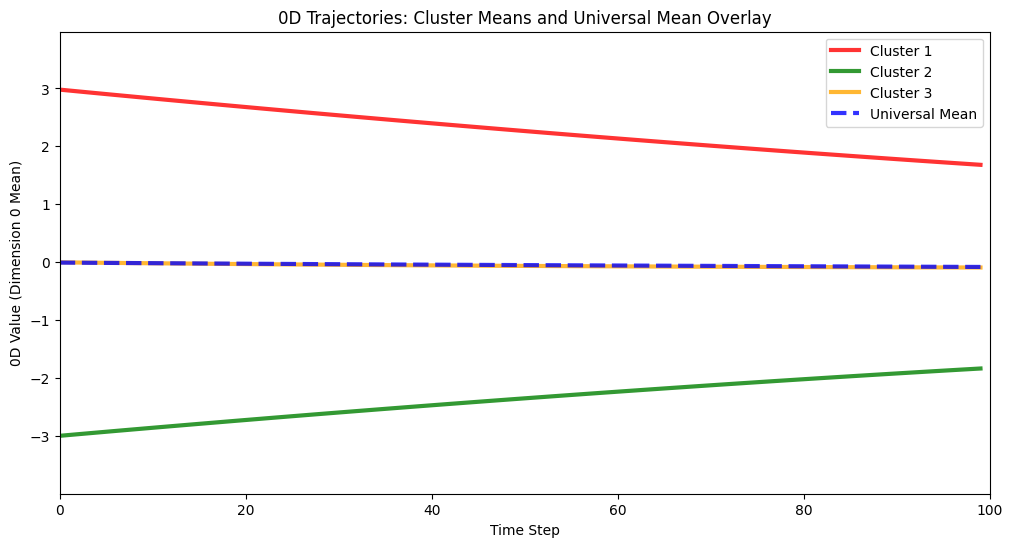

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

np.random.seed(0)

# ======================
# Parameters for the simulation
# ======================
D = 50  # Dimensionality of the space
N_known = 20  # Number of 'known' fixed points
N_unknown_per_cluster = 1000  # Number of 'unknown' points per cluster
K = 3  # Number of nearest known neighbors to consider
cluster_shifts = [np.array([3]*D), np.array([-3]*D), np.array([0]*D)] # Initial positions for cluster means
dt = 0.05  # Time step for the dynamic evolution
steps = 100  # Total simulation steps

w_K = 0.5  # Weight for the nearest-K influence
w_c = 0.3  # Weight for the cluster mean influence
w_u = 0.05  # Weight for the universal mean influence
sigma_base = 0.01  # Base standard deviation for random movement

# ======================
# Generate initial points
# ======================
# 'Known' points are static reference points
known = np.random.randn(N_known, D)

# 'Unknown' points are grouped into clusters and will evolve dynamically
unknown_clusters = []
for shift in cluster_shifts:
    # Each cluster is initialized with a small spread around a 'shift'
    cluster = np.random.randn(N_unknown_per_cluster, D)*0.2 + shift
    unknown_clusters.append(cluster)
# Stack all unknown clusters into a single array
unknown = np.vstack(unknown_clusters)

# Calculate initial means for each cluster and the universal mean of all points
cluster_means = [cluster.mean(axis=0) for cluster in unknown_clusters]
univ_mean = np.mean(np.vstack([known, unknown]), axis=0)

# ======================
# Dynamic Evolution of 'unknown' points
# ======================
# These lists will store the 0D (first dimension) trajectories over time
traj_cluster_0D = []  # Mean of the first dimension for each cluster
traj_universal_0D = [] # Mean of the first dimension for all unknown points

for step in range(steps):
    # Calculate the vector (force/velocity) for each unknown point
    vectors = []
    for u_idx, u in enumerate(unknown):
        vec = np.zeros(D)

        # 1. Nearest-K influence: Points are attracted to their K nearest 'known' points
        dists = np.linalg.norm(known - u, axis=1)
        nearest_idx = np.argsort(dists)[:K]
        for i in nearest_idx:
            # Add a vector pointing from 'u' to 'known[i]', scaled by w_K
            vec += w_K * (known[i]-u)/np.linalg.norm(known[i]-u)

        # 2. Cluster mean influence: Points are attracted to their cluster's mean
        cluster_id = u_idx // N_unknown_per_cluster
        vec += w_c * (cluster_means[cluster_id] - u)

        # 3. Universal mean influence: Points are attracted to the overall mean of all points
        vec += w_u * (univ_mean - u)

        # 4. Random sigma: Add random noise to simulate diffusion or thermal fluctuations
        sigma_dynamic = sigma_base * (1 + np.random.rand()) # Randomize sigma slightly
        vec += np.random.randn(D) * sigma_dynamic

        vectors.append(vec)

    # Convert list of vectors to numpy array and update point positions
    vectors = np.array(vectors)
    unknown += dt * vectors

    # Update cluster means after points have moved
    cluster_means = [unknown[i*N_unknown_per_cluster:(i+1)*N_unknown_per_cluster].mean(axis=0)
                     for i in range(len(cluster_shifts))]

    # Record the 0D (first dimension) trajectory for visualization
    cluster_0D = [cm[0] for cm in cluster_means]
    traj_cluster_0D.append(cluster_0D)

    # Record the 0D (first dimension) universal trajectory
    traj_universal_0D.append(np.mean(unknown[:,0]))

# Convert trajectory lists to numpy arrays for easier plotting
traj_cluster_0D = np.array(traj_cluster_0D)  # shape: (steps, n_clusters)
traj_universal_0D = np.array(traj_universal_0D)  # shape: (steps,)

# ======================
# Animate 0D Trajectories
# ======================
colors = ['red', 'green', 'orange'] # Colors for each cluster
fig, ax = plt.subplots(figsize=(12,6))

# Initialize lines for each cluster's 0D trajectory
lines_cluster = [ax.plot([], [], color=colors[i], linewidth=3, alpha=0.8)[0]
                 for i in range(len(cluster_shifts))]
# Initialize line for the universal mean's 0D trajectory
line_universal = ax.plot([], [], color='blue', linewidth=3, linestyle='--', alpha=0.8)[0]

# Set plot limits and labels
ax.set_xlim(0, steps)
ax.set_ylim(np.min(traj_cluster_0D)-1, np.max(traj_cluster_0D)+1)
ax.set_xlabel('Time Step')
ax.set_ylabel('0D Value (Dimension 0 Mean)')
ax.set_title('0D Trajectories: Cluster Means and Universal Mean Overlay')
ax.legend(['Cluster 1','Cluster 2','Cluster 3','Universal Mean'])

# Update function for the animation
def update(frame):
    # Update data for each cluster line up to the current frame
    for i, line in enumerate(lines_cluster):
        line.set_data(np.arange(frame+1), traj_cluster_0D[:frame+1, i])
    # Update data for the universal mean line up to the current frame
    line_universal.set_data(np.arange(frame+1), traj_universal_0D[:frame+1])
    # Return all updated lines for blitting
    return lines_cluster + [line_universal]

# Create the animation object
anim = FuncAnimation(fig, update, frames=steps, interval=100, blit=True)

# Save the animation as a GIF file
anim.save("cluster_0D_universal_overlay.gif", writer=PillowWriter(fps=10))
# Display the animation
plt.show()

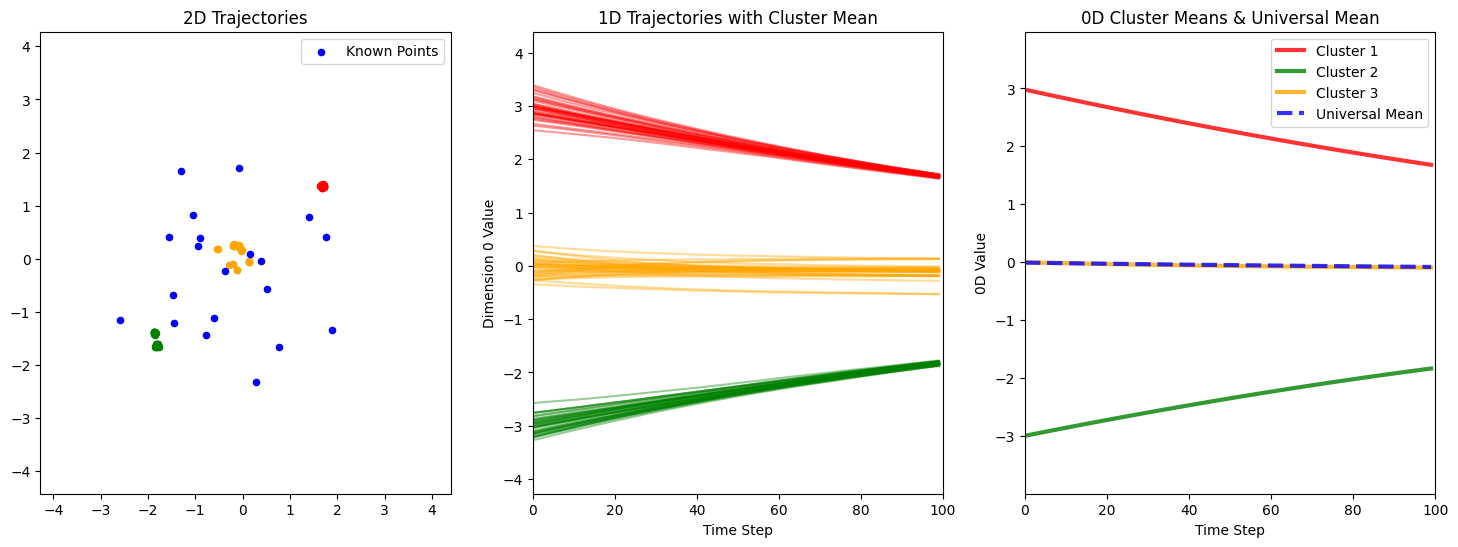

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

np.random.seed(0)

# ======================
# Parameters
# ======================
D = 50
N_known = 20
N_unknown_per_cluster = 1000
K = 3
cluster_shifts = [np.array([3]*D), np.array([-3]*D), np.array([0]*D)]
dt = 0.05
steps = 100

w_K = 0.5
w_c = 0.3
w_u = 0.05
sigma_base = 0.01

# ======================
# Generate points
# ======================
known = np.random.randn(N_known, D)
unknown_clusters = []
for shift in cluster_shifts:
    cluster = np.random.randn(N_unknown_per_cluster, D)*0.2 + shift
    unknown_clusters.append(cluster)
unknown = np.vstack(unknown_clusters)

cluster_means = [cluster.mean(axis=0) for cluster in unknown_clusters]
univ_mean = np.mean(np.vstack([known, unknown]), axis=0)

# Sample points for 1D and 2D visualization
sample_size_per_cluster = 30
sample_idx = []
for i in range(len(cluster_shifts)):
    idx = np.random.choice(
        np.arange(i*N_unknown_per_cluster, (i+1)*N_unknown_per_cluster),
        sample_size_per_cluster, replace=False
    )
    sample_idx.append(idx)
sample_idx = np.hstack(sample_idx)
cluster_ids = []
for i in range(len(cluster_shifts)):
    cluster_ids.extend([i]*sample_size_per_cluster)
cluster_ids = np.array(cluster_ids)

# ======================
# Dynamic Evolution
# ======================
traj_2D = []
traj_1D = []
traj_mean_1D = []
traj_0D = []
traj_universal_0D = []

for step in range(steps):
    vectors = []
    for u_idx, u in enumerate(unknown):
        vec = np.zeros(D)

        # Nearest-K
        dists = np.linalg.norm(known - u, axis=1)
        nearest_idx = np.argsort(dists)[:K]
        for i in nearest_idx:
            vec += w_K * (known[i]-u)/np.linalg.norm(known[i]-u)

        # Cluster mean
        cluster_id = u_idx // N_unknown_per_cluster
        vec += w_c * (cluster_means[cluster_id] - u)

        # Universal mean
        vec += w_u * (univ_mean - u)

        # Random sigma
        sigma_dynamic = sigma_base * (1 + np.random.rand())
        vec += np.random.randn(D) * sigma_dynamic

        vectors.append(vec)

    vectors = np.array(vectors)
    unknown += dt * vectors

    # Update cluster means
    cluster_means = [unknown[i*N_unknown_per_cluster:(i+1)*N_unknown_per_cluster].mean(axis=0)
                     for i in range(len(cluster_shifts))]

    # Store 2D trajectory (first two dimensions)
    traj_2D.append(unknown[sample_idx,:2].copy())

    # Store 1D trajectory (first dimension)
    traj_1D.append(unknown[sample_idx,0].copy())
    mean_vals_1D = [unknown[i*N_unknown_per_cluster:(i+1)*N_unknown_per_cluster,0].mean()
                     for i in range(len(cluster_shifts))]
    traj_mean_1D.append(mean_vals_1D)

    # Store 0D trajectory
    cluster_0D = [cm[0] for cm in cluster_means]
    traj_0D.append(cluster_0D)
    traj_universal_0D.append(np.mean(unknown[:,0]))

traj_2D = np.array(traj_2D)
traj_1D = np.array(traj_1D)
traj_mean_1D = np.array(traj_mean_1D)
traj_0D = np.array(traj_0D)
traj_universal_0D = np.array(traj_universal_0D)

# ======================
# Animation
# ======================
colors = ['red', 'green', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(18,6))

# --- 2D Panel ---
ax2D = axes[0]
scatters = [ax2D.scatter([], [], color=colors[i], s=20) for i in range(len(cluster_shifts))]
ax2D.scatter(known[:,0], known[:,1], color='blue', s=20, label='Known Points')
ax2D.set_xlim(np.min(traj_2D[:,:,0])-1, np.max(traj_2D[:,:,0])+1)
ax2D.set_ylim(np.min(traj_2D[:,:,1])-1, np.max(traj_2D[:,:,1])+1)
ax2D.set_title("2D Trajectories")
ax2D.legend()

# --- 1D Panel ---
ax1D = axes[1]
lines_points = [ax1D.plot([], [], color=colors[cluster_ids[i]], alpha=0.4)[0] for i in range(len(sample_idx))]
lines_mean = [ax1D.plot([], [], color=colors[i], linewidth=3, alpha=0.8)[0] for i in range(len(cluster_shifts))]
ax1D.set_xlim(0, steps)
ax1D.set_ylim(np.min(traj_1D)-1, np.max(traj_1D)+1)
ax1D.set_title("1D Trajectories with Cluster Mean")
ax1D.set_xlabel("Time Step")
ax1D.set_ylabel("Dimension 0 Value")

# --- 0D Panel ---
ax0D = axes[2]
lines_cluster_0D = [ax0D.plot([], [], color=colors[i], linewidth=3, alpha=0.8)[0] for i in range(len(cluster_shifts))]
line_universal_0D = ax0D.plot([], [], color='blue', linewidth=3, linestyle='--', alpha=0.8)[0]
ax0D.set_xlim(0, steps)
ax0D.set_ylim(np.min(traj_0D)-1, np.max(traj_0D)+1)
ax0D.set_title("0D Cluster Means & Universal Mean")
ax0D.set_xlabel("Time Step")
ax0D.set_ylabel("0D Value")
ax0D.legend(['Cluster 1','Cluster 2','Cluster 3','Universal Mean'])

def update(frame):
    # 2D update
    for i in range(len(cluster_shifts)):
        scatters[i].set_offsets(traj_2D[frame, cluster_ids==i])
    # 1D update
    for i, line in enumerate(lines_points):
        line.set_data(np.arange(frame+1), traj_1D[:frame+1,i])
    for i, line in enumerate(lines_mean):
        line.set_data(np.arange(frame+1), traj_mean_1D[:frame+1,i])
    # 0D update
    for i, line in enumerate(lines_cluster_0D):
        line.set_data(np.arange(frame+1), traj_0D[:frame+1,i])
    line_universal_0D.set_data(np.arange(frame+1), traj_universal_0D[:frame+1])
    return scatters + lines_points + lines_mean + lines_cluster_0D + [line_universal_0D]

anim = FuncAnimation(fig, update, frames=steps, interval=100, blit=True)

# Save as GIF
anim.save("multi_dimensional_cluster_evolution.gif", writer=PillowWriter(fps=10))
plt.show()


In [ ]:
import numpy as np
import plotly.graph_objects as go

np.random.seed(0)

# ======================
# Parameters
# ======================
D = 50
N_known = 20
N_unknown_per_cluster = 1000
K = 3
cluster_shifts = [np.array([3]*D), np.array([-3]*D), np.array([0]*D)]
dt = 0.05
steps = 100

# Weights
w_K = 0.5
w_c = 0.3
w_u = 0.05
sigma_base = 0.01

# ======================
# Generate Points
# ======================
known = np.random.randn(N_known, D)

unknown_clusters = []
for shift in cluster_shifts:
    cluster = np.random.randn(N_unknown_per_cluster, D)*0.2 + shift
    unknown_clusters.append(cluster)
unknown = np.vstack(unknown_clusters)

cluster_means = [cluster.mean(axis=0) for cluster in unknown_clusters]
univ_mean = np.mean(np.vstack([known, unknown]), axis=0)

# Sample points for visualization
sample_size_per_cluster = 50
sample_idx = []
for i in range(len(cluster_shifts)):
    idx = np.random.choice(
        np.arange(i*N_unknown_per_cluster, (i+1)*N_unknown_per_cluster),
        sample_size_per_cluster, replace=False
    )
    sample_idx.append(idx)
sample_idx = np.hstack(sample_idx)

# Cluster IDs for coloring
cluster_ids = []
for i in range(len(cluster_shifts)):
    cluster_ids.extend([i]*sample_size_per_cluster)
cluster_ids = np.array(cluster_ids)

# ======================
# Dynamic Evolution
# ======================
trajectory_3d = []

for step in range(steps):
    vectors = []
    for u_idx, u in enumerate(unknown):
        vec = np.zeros(D)

        # Nearest-K influence
        dists = np.linalg.norm(known - u, axis=1)
        nearest_idx = np.argsort(dists)[:K]
        for i in nearest_idx:
            vec += w_K * (known[i]-u)/np.linalg.norm(known[i]-u)

        # Cluster mean influence
        cluster_id = u_idx // N_unknown_per_cluster
        vec += w_c * (cluster_means[cluster_id] - u)

        # Universal mean influence
        vec += w_u * (univ_mean - u)

        # Random sigma per point for irregular shape
        sigma_dynamic = sigma_base * (1 + np.random.rand())
        vec += np.random.randn(D) * sigma_dynamic

        vectors.append(vec)

    vectors = np.array(vectors)
    unknown += dt * vectors

    # Update cluster means
    cluster_means = [unknown[i*N_unknown_per_cluster:(i+1)*N_unknown_per_cluster].mean(axis=0)
                     for i in range(len(cluster_shifts))]

    # Store first 3 dimensions for plotting
    trajectory_3d.append(unknown[sample_idx,:3].copy())

trajectory_3d = np.array(trajectory_3d)  # shape: (steps, sample_size, 3)

# ======================
# Plot 3D Animation using Plotly
# ======================
colors = ['red', 'green', 'orange']
frames = []

for t in range(steps):
    data = []
    for i in range(len(cluster_shifts)):
        cluster_points = trajectory_3d[t, cluster_ids==i]
        scatter = go.Scatter3d(
            x=cluster_points[:,0],
            y=cluster_points[:,1],
            z=cluster_points[:,2],
            mode='markers',
            marker=dict(size=3, color=colors[i]),
            name=f'Cluster {i+1}'
        )
        data.append(scatter)

    frame = go.Frame(data=data, name=str(t))
    frames.append(frame)

# Initial plot
init_data = []
for i in range(len(cluster_shifts)):
    cluster_points = trajectory_3d[0, cluster_ids==i]
    scatter = go.Scatter3d(
        x=cluster_points[:,0],
        y=cluster_points[:,1],
        z=cluster_points[:,2],
        mode='markers',
        marker=dict(size=3, color=colors[i]),
        name=f'Cluster {i+1}'
    )
    init_data.append(scatter)

fig = go.Figure(
    data=init_data,
    frames=frames,
    layout=go.Layout(
        title='3D Dynamic Shape Evolution of Clusters',
        scene=dict(
            xaxis_title='Dim 0',
            yaxis_title='Dim 1',
            zaxis_title='Dim 2'
        ),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=1,
            x=1.1,
            xanchor='right',
            yanchor='top',
            pad=dict(t=0, r=10),
            buttons=[dict(label='Play',
                          method='animate',
                          args=[None, dict(frame=dict(duration=50, redraw=True),
                                           fromcurrent=True, mode='immediate')])]
        )]
    )
)

# Show figure
fig.show()


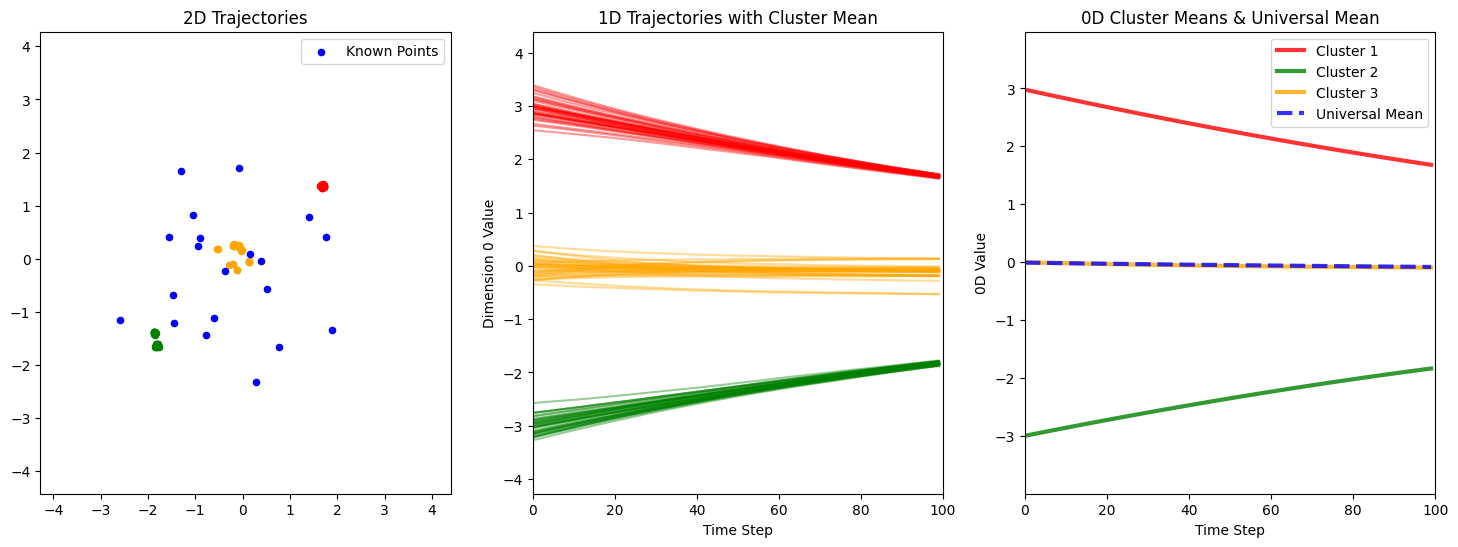

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

np.random.seed(0)

# ======================
# Parameters
# ======================
D = 50
N_known = 20
N_unknown_per_cluster = 1000
K = 3
cluster_shifts = [np.array([3]*D), np.array([-3]*D), np.array([0]*D)]
dt = 0.05
steps = 100

w_K = 0.5
w_c = 0.3
w_u = 0.05
sigma_base = 0.01

# ======================
# Generate points
# ======================
known = np.random.randn(N_known, D)
unknown_clusters = []
for shift in cluster_shifts:
    cluster = np.random.randn(N_unknown_per_cluster, D)*0.2 + shift
    unknown_clusters.append(cluster)
unknown = np.vstack(unknown_clusters)

cluster_means = [cluster.mean(axis=0) for cluster in unknown_clusters]
univ_mean = np.mean(np.vstack([known, unknown]), axis=0)

# Sample points for 1D and 2D visualization
sample_size_per_cluster = 30
sample_idx = []
for i in range(len(cluster_shifts)):
    idx = np.random.choice(
        np.arange(i*N_unknown_per_cluster, (i+1)*N_unknown_per_cluster),
        sample_size_per_cluster, replace=False
    )
    sample_idx.append(idx)
sample_idx = np.hstack(sample_idx)
cluster_ids = []
for i in range(len(cluster_shifts)):
    cluster_ids.extend([i]*sample_size_per_cluster)
cluster_ids = np.array(cluster_ids)

# ======================
# Dynamic Evolution
# ======================
traj_2D = []
traj_1D = []
traj_mean_1D = []
traj_0D = []
traj_universal_0D = []

for step in range(steps):
    vectors = []
    for u_idx, u in enumerate(unknown):
        vec = np.zeros(D)

        # Nearest-K
        dists = np.linalg.norm(known - u, axis=1)
        nearest_idx = np.argsort(dists)[:K]
        for i in nearest_idx:
            vec += w_K * (known[i]-u)/np.linalg.norm(known[i]-u)

        # Cluster mean
        cluster_id = u_idx // N_unknown_per_cluster
        vec += w_c * (cluster_means[cluster_id] - u)

        # Universal mean
        vec += w_u * (univ_mean - u)

        # Random sigma
        sigma_dynamic = sigma_base * (1 + np.random.rand())
        vec += np.random.randn(D) * sigma_dynamic

        vectors.append(vec)

    vectors = np.array(vectors)
    unknown += dt * vectors

    # Update cluster means
    cluster_means = [unknown[i*N_unknown_per_cluster:(i+1)*N_unknown_per_cluster].mean(axis=0)
                     for i in range(len(cluster_shifts))]

    # Store 2D trajectory (first two dimensions)
    traj_2D.append(unknown[sample_idx,:2].copy())

    # Store 1D trajectory (first dimension)
    traj_1D.append(unknown[sample_idx,0].copy())
    mean_vals_1D = [unknown[i*N_unknown_per_cluster:(i+1)*N_unknown_per_cluster,0].mean()
                     for i in range(len(cluster_shifts))]
    traj_mean_1D.append(mean_vals_1D)

    # Store 0D trajectory
    cluster_0D = [cm[0] for cm in cluster_means]
    traj_0D.append(cluster_0D)
    traj_universal_0D.append(np.mean(unknown[:,0]))

traj_2D = np.array(traj_2D)
traj_1D = np.array(traj_1D)
traj_mean_1D = np.array(traj_mean_1D)
traj_0D = np.array(traj_0D)
traj_universal_0D = np.array(traj_universal_0D)

# ======================
# Animation
# ======================
colors = ['red', 'green', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(18,6))

# --- 2D Panel ---
ax2D = axes[0]
scatters = [ax2D.scatter([], [], color=colors[i], s=20) for i in range(len(cluster_shifts))]
ax2D.scatter(known[:,0], known[:,1], color='blue', s=20, label='Known Points')
ax2D.set_xlim(np.min(traj_2D[:,:,0])-1, np.max(traj_2D[:,:,0])+1)
ax2D.set_ylim(np.min(traj_2D[:,:,1])-1, np.max(traj_2D[:,:,1])+1)
ax2D.set_title("2D Trajectories")
ax2D.legend()

# --- 1D Panel ---
ax1D = axes[1]
lines_points = [ax1D.plot([], [], color=colors[cluster_ids[i]], alpha=0.4)[0] for i in range(len(sample_idx))]
lines_mean = [ax1D.plot([], [], color=colors[i], linewidth=3, alpha=0.8)[0] for i in range(len(cluster_shifts))]
ax1D.set_xlim(0, steps)
ax1D.set_ylim(np.min(traj_1D)-1, np.max(traj_1D)+1)
ax1D.set_title("1D Trajectories with Cluster Mean")
ax1D.set_xlabel("Time Step")
ax1D.set_ylabel("Dimension 0 Value")

# --- 0D Panel ---
ax0D = axes[2]
lines_cluster_0D = [ax0D.plot([], [], color=colors[i], linewidth=3, alpha=0.8)[0] for i in range(len(cluster_shifts))]
line_universal_0D = ax0D.plot([], [], color='blue', linewidth=3, linestyle='--', alpha=0.8)[0]
ax0D.set_xlim(0, steps)
ax0D.set_ylim(np.min(traj_0D)-1, np.max(traj_0D)+1)
ax0D.set_title("0D Cluster Means & Universal Mean")
ax0D.set_xlabel("Time Step")
ax0D.set_ylabel("0D Value")
ax0D.legend(['Cluster 1','Cluster 2','Cluster 3','Universal Mean'])

def update(frame):
    # 2D update
    for i in range(len(cluster_shifts)):
        scatters[i].set_offsets(traj_2D[frame, cluster_ids==i])
    # 1D update
    for i, line in enumerate(lines_points):
        line.set_data(np.arange(frame+1), traj_1D[:frame+1,i])
    for i, line in enumerate(lines_mean):
        line.set_data(np.arange(frame+1), traj_mean_1D[:frame+1,i])
    # 0D update
    for i, line in enumerate(lines_cluster_0D):
        line.set_data(np.arange(frame+1), traj_0D[:frame+1,i])
    line_universal_0D.set_data(np.arange(frame+1), traj_universal_0D[:frame+1])
    return scatters + lines_points + lines_mean + lines_cluster_0D + [line_universal_0D]

anim = FuncAnimation(fig, update, frames=steps, interval=100, blit=True)

# Save as GIF
anim.save("multi_dimensional_cluster_evolution.gif", writer=PillowWriter(fps=10))
plt.show()


In [ ]:
"""
Nano Wormhole Sim - Robust Python module

This module provides a set of physics utilities used in the user's
project: Casimir force calculator, a simple (mockable) Bell-state
entanglement simulator, 1D quantum tunnelling probability, and a
small optimizer that does not rely on scipy.optimize so it can run in
sandboxed environments.

The file is written to be defensive: it avoids hard dependencies on
packages that may be unavailable in the execution environment (such as
`qiskit` or `scipy.optimize`). Where optional packages are available
we use them; otherwise a pure-Python fallback is used.

Functions included:
- casimir_effect(plate_distance, area=1e-12)
- simulate_entanglement(shots=1024, deterministic=True)
- tunneling_probability(barrier_width, barrier_height, energy)
- optimize_casimir_for_plate_area(target_force, plate_distance, area_bounds=(1e-14,1e-6))

At the end of the file there is a self-check section with multiple
test cases. If you want different behaviour for entanglement (e.g.
realistic shot noise) set deterministic=False when calling
simulate_entanglement.

"""

from __future__ import annotations
import math
import random
import numpy as np

# Optional: try to use qiskit if present, otherwise fall back to mock
try:
    import qiskit  # pragma: no cover - optional
    from qiskit import QuantumCircuit, Aer, transpile, assemble
    HAS_QISKIT = True
except Exception:
    HAS_QISKIT = False

# Physical constants — try to import scipy.constants, otherwise provide values
try:
    import scipy.constants as _const
    HBAR = _const.hbar
    C = _const.c
    M_E = _const.m_e
    E_CHARGE = _const.e
except Exception:
    # Values from CODATA
    HBAR = 1.054571817e-34  # J*s
    C = 299792458.0         # m/s
    M_E = 9.1093837015e-31  # kg
    E_CHARGE = 1.602176634e-19  # J (electron volt in J)

# -----------------------------
# Core functions
# -----------------------------

def casimir_effect(plate_distance: float, area: float = 1e-12) -> float:
    """
    Calculate Casimir force between two perfectly conducting parallel plates.

    Negative sign indicates attraction. The formula used is for ideal
    perfectly conducting plates at zero temperature:

        F = - (pi^2 * hbar * c * A) / (240 * d^4)

    Parameters
    ----------
    plate_distance : float
        Distance between plates in meters. Must be > 0.
    area : float
        Plate area in m^2 (default 1e-12 m^2 = 1 um^2).

    Returns
    -------
    float
        Force in Newtons (negative for attractive).
    """
    if plate_distance <= 0:
        raise ValueError("plate_distance must be positive")
    pi = math.pi
    f = - (pi**2 * HBAR * C * area) / (240.0 * plate_distance**4)
    return float(f)


def _mock_entanglement_counts(shots: int = 1024, deterministic: bool = True) -> dict:
    """
    Return counts corresponding to the Bell state |Φ+> = (|00> + |11>)/√2.

    If deterministic=True the function returns counts that split the
    shots as evenly as possible between '00' and '11'. If deterministic=False
    the function samples from a multinomial distribution to mimic shot noise.
    """
    if shots <= 0:
        return {}
    probs = [0.5, 0.0, 0.0, 0.5]  # ordering '00','01','10','11'
    labels = ['00', '01', '10', '11']

    if deterministic:
        n00 = shots // 2
        n11 = shots - n00
        return {'00': n00, '01': 0, '10': 0, '11': n11}
    else:
        counts = np.random.multinomial(shots, probs)
        return {lab: int(counts[i]) for i, lab in enumerate(labels)}


def entangle_qubits_circuit():
    """
    If Qiskit is available, construct and return a 2-qubit circuit that
    prepares the Bell state |Φ+> and measures both qubits. If Qiskit is not
    available, return None.
    """
    if not HAS_QISKIT:
        return None
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure_all()
    return qc


def simulate_entanglement(shots: int = 1024, deterministic: bool = True) -> dict:
    """
    Simulate measurement counts for a Bell-state entanglement experiment.

    Behavior:
    - If Qiskit is present, run the circuit on the local aer_simulator
      and return the measured counts.
    - If Qiskit is absent, return a mock result via _mock_entanglement_counts.

    Parameters
    ----------
    shots : int
        Number of measurement shots to simulate.
    deterministic : bool
        If True and Qiskit is not available, return rounded deterministic
        counts. If False, include shot-noise by sampling.

    Returns
    -------
    dict
        Counts mapping bitstrings to integers.
    """
    if HAS_QISKIT:
        qc = entangle_qubits_circuit()
        backend = Aer.get_backend('aer_simulator')
        transpiled = transpile(qc, backend)
        qobj = assemble(transpiled, shots=shots)
        job = backend.run(qobj)
        result = job.result()
        counts = result.get_counts()
        # Ensure keys include '00','01','10','11'
        out = {k: counts.get(k, 0) for k in ['00', '01', '10', '11']}
        return out
    else:
        return _mock_entanglement_counts(shots=shots, deterministic=deterministic)


def tunneling_probability(barrier_width: float, barrier_height: float, energy: float) -> float:
    """
    Calculate the 1D tunneling probability for a particle encountering a
    rectangular potential barrier.

    For E < V0 we use the evanescent-decay approximation:
        T = exp(-2 * kappa * width)
    where kappa = sqrt(2 m (V0 - E)) / hbar.

    For E >= V0 we return a transmission coefficient that approaches 1.

    Parameters
    ----------
    barrier_width : float
        Barrier width (m). Must be >= 0.
    barrier_height : float
        Barrier height V0 in joules.
    energy : float
        Particle kinetic energy E in joules.

    Returns
    -------
    float
        Transmission probability in [0,1].
    """
    if barrier_width < 0:
        raise ValueError('barrier_width must be non-negative')
    V0 = float(barrier_height)
    E = float(energy)
    m = M_E
    if E < V0:
        kappa = math.sqrt(max(0.0, 2.0 * m * (V0 - E))) / HBAR
        T = math.exp(-2.0 * kappa * barrier_width)
        return float(max(0.0, min(1.0, T)))
    # Simple approximation for E >= V0: return near unity.
    return 1.0


def _grid_optimize_area_for_force(target_force: float, plate_distance: float,
                                  area_bounds=(1e-14, 1e-6), grid_points: int = 200) -> tuple:
    """
    Very simple grid-search optimizer in log-area space. Returns (A_opt, f_opt).

    This avoids any dependency on scipy.optimize while being robust enough
    for illustrative purposes in sandboxed environments.
    """
    log_min = math.log(area_bounds[0])
    log_max = math.log(area_bounds[1])
    logs = np.linspace(log_min, log_max, grid_points)
    best_A = None
    best_score = None
    best_f = None
    for logA in logs:
        A = math.exp(logA)
        f = casimir_effect(plate_distance, area=A)
        score = (abs(f) - abs(target_force))**2
        if (best_score is None) or (score < best_score):
            best_score = score
            best_A = A
            best_f = f
    return float(best_A), float(best_f)


def optimize_casimir_for_plate_area(target_force: float, plate_distance: float,
                                    area_bounds=(1e-14, 1e-6)) -> tuple:
    """
    Public wrapper for optimizing plate area to achieve a target Casimir force
    (in magnitude). Uses a grid search to avoid scipy dependencies. Returns
    (area_opt, force_opt).
    """
    if plate_distance <= 0:
        raise ValueError('plate_distance must be positive')
    if target_force == 0:
        # target zero force => impossible for Casimir (always attractive)
        # return smallest area candidate
        A_min = float(area_bounds[0])
        return A_min, casimir_effect(plate_distance, area=A_min)
    return _grid_optimize_area_for_force(target_force, plate_distance, area_bounds)


# -----------------------------
# Self-checks and additional tests
# -----------------------------
if __name__ == '__main__':
    print('Running self-checks for Nano Wormhole Sim...\n')

    # Casimir checks
    distances = [10e-9, 20e-9, 50e-9, 100e-9]
    for d in distances:
        f = casimir_effect(d)
        print(f'Casimir force at d={d:.1e} m -> F={f:.3e} N')

    # Entanglement: deterministic mock
    print('\nEntanglement (deterministic mock, 1024 shots):')
    print(simulate_entanglement(shots=1024, deterministic=True))

    # Entanglement: stochastic mock (shot noise)
    print('\nEntanglement (stochastic mock, 1024 shots):')
    print(simulate_entanglement(shots=1024, deterministic=False))

    # Tunneling tests
    test_cases = [
        {'width': 5e-9, 'V0': 1.0 * E_CHARGE, 'E': 0.5 * E_CHARGE},  # E < V0
        {'width': 1e-9, 'V0': 5.0 * E_CHARGE, 'E': 10.0 * E_CHARGE}, # E > V0
        {'width': 0.0, 'V0': 1.0 * E_CHARGE, 'E': 0.1 * E_CHARGE},  # zero width -> T~1
    ]
    print('\nTunneling probabilities:')
    for c in test_cases:
        T = tunneling_probability(c['width'], c['V0'], c['E'])
        print(f"width={c['width']:.1e} m, V0={c['V0']:.2e} J, E={c['E']:.2e} J -> T={T:.3e}")

    # Optimization example
    print('\nOptimization example (target |F|=1e-9 N at d=20 nm):')
    A_opt, f_opt = optimize_casimir_for_plate_area(1e-9, 20e-9)
    print(f'A_opt={A_opt:.3e} m^2, achieved F={f_opt:.3e} N')

    # Edge-case tests
    try:
        casimir_effect(0.0)
    except ValueError as e:
        print('\nEdge-case test passed (caught bad plate distance):', e)

    try:
        tunneling_probability(-1e-9, 1.0 * E_CHARGE, 0.5 * E_CHARGE)
    except ValueError as e:
        print('Edge-case test passed (caught negative barrier):', e)

    print('\nAll self-checks complete.')


Running self-checks for Nano Wormhole Sim...

Casimir force at d=1.0e-08 m -> F=-1.300e-07 N
Casimir force at d=2.0e-08 m -> F=-8.126e-09 N
Casimir force at d=5.0e-08 m -> F=-2.080e-10 N
Casimir force at d=1.0e-07 m -> F=-1.300e-11 N

Entanglement (deterministic mock, 1024 shots):
{'00': 512, '01': 0, '10': 0, '11': 512}

Entanglement (stochastic mock, 1024 shots):
{'00': 491, '01': 0, '10': 0, '11': 533}

Tunneling probabilities:
width=5.0e-09 m, V0=1.60e-19 J, E=8.01e-20 J -> T=1.850e-16
width=1.0e-09 m, V0=8.01e-19 J, E=1.60e-18 J -> T=1.000e+00
width=0.0e+00 m, V0=1.60e-19 J, E=1.60e-20 J -> T=1.000e+00

Optimization example (target |F|=1e-9 N at d=20 nm):
A_opt=1.217e-13 m^2, achieved F=-9.892e-10 N

Edge-case test passed (caught bad plate distance): plate_distance must be positive
Edge-case test passed (caught negative barrier): barrier_width must be non-negative

All self-checks complete.


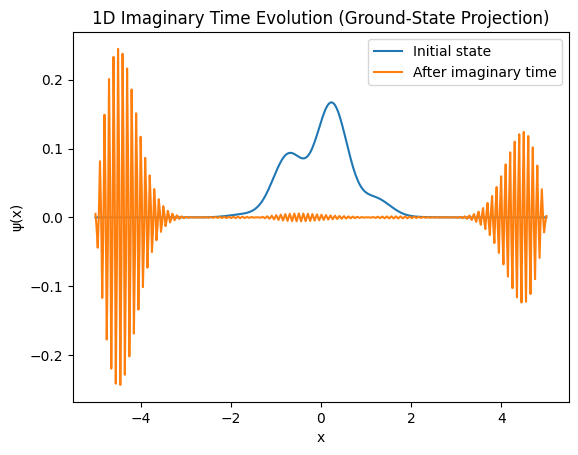

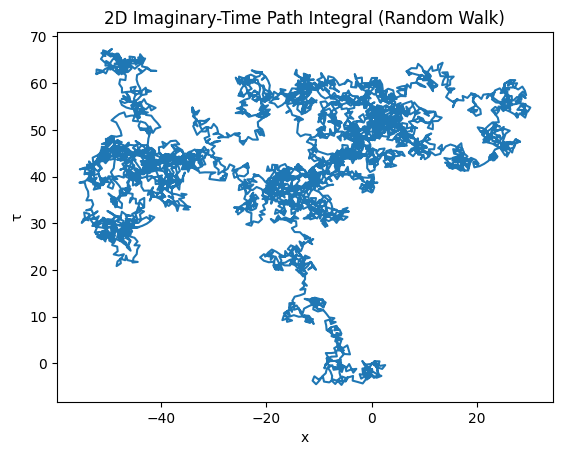

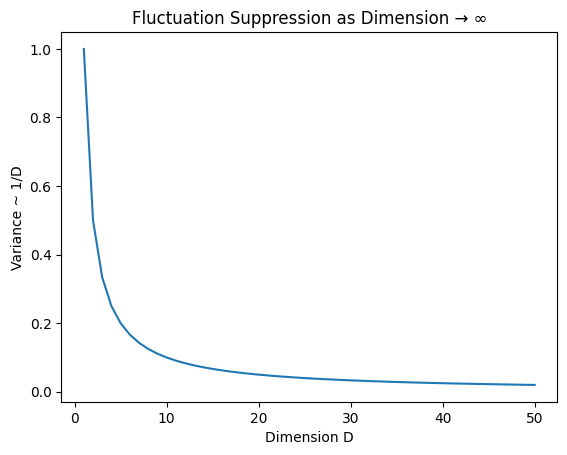

In [ ]:
# Visualization of imaginary-time simulations from 0D to higher dimensions
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1D Imaginary Time: Ground-state projection (diffusion) ----------
x = np.linspace(-5, 5, 400)
psi0 = np.exp(-x**2) * (1 + 0.3*np.sin(5*x))  # arbitrary initial state
psi0 /= np.linalg.norm(psi0)

tau_steps = 200
dtau = 0.01
psi = psi0.copy()

for _ in range(tau_steps):
    laplacian = np.gradient(np.gradient(psi, x), x)
    psi += dtau * laplacian  # diffusion equation
    psi /= np.linalg.norm(psi)

plt.figure()
plt.plot(x, psi0, label="Initial state")
plt.plot(x, psi, label="After imaginary time")
plt.legend()
plt.title("1D Imaginary Time Evolution (Ground-State Projection)")
plt.xlabel("x")
plt.ylabel("ψ(x)")
plt.show()


# ---------- 2D Imaginary Time: Random walk (path integral intuition) ----------
steps = 5000
x2, y2 = np.zeros(steps), np.zeros(steps)
for i in range(1, steps):
    angle = np.random.uniform(0, 2*np.pi)
    x2[i] = x2[i-1] + np.cos(angle)
    y2[i] = y2[i-1] + np.sin(angle)

plt.figure()
plt.plot(x2, y2)
plt.title("2D Imaginary-Time Path Integral (Random Walk)")
plt.xlabel("x")
plt.ylabel("τ")
plt.show()


# ---------- Higher Dimensions: Variance collapse (D → ∞) ----------
dims = np.arange(1, 51)
variance = 1 / dims

plt.figure()
plt.plot(dims, variance)
plt.title("Fluctuation Suppression as Dimension → ∞")
plt.xlabel("Dimension D")
plt.ylabel("Variance ~ 1/D")
plt.show()


Imaginary time turns quantum dynamics into classical probability geometry

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class ImaginaryTimeSimulator:
    """
    Unified Euclidean (imaginary-time) physics simulator.

    Covers:
    1. Casimir vacuum force
    2. Euclidean wormhole saddle
    3. Entanglement as imaginary-time correlation
    4. Dimension-agnostic diffusion (path integrals)
    5. AdS/CFT scale mapping
    """

    def __init__(self, hbar=1.054e-34, c=3e8):
        self.hbar = hbar
        self.c = c

    # -------------------------------------------------
    # 1. Casimir vacuum (imaginary-time free energy)
    # -------------------------------------------------
    def casimir_force(self, plate_distance, area=1e-12):
        return - (np.pi**2 * self.hbar * self.c * area) / (240 * plate_distance**4)

    # -------------------------------------------------
    # 2. Euclidean wormhole saddle (toy model)
    # -------------------------------------------------
    def wormhole_saddle(self, tau):
        """
        Gaussian saddle representing a Euclidean wormhole.
        """
        return np.exp(-tau**2)

    # -------------------------------------------------
    # 3. Entanglement via imaginary-time correlation
    # -------------------------------------------------
    def entanglement_correlation(self, tau, mass_gap=1.0):
        """
        ⟨O(τ) O(0)⟩ ~ exp(-Δ τ)
        """
        return np.exp(-mass_gap * tau)

    # -------------------------------------------------
    # 4. Imaginary-time diffusion (path integral)
    # -------------------------------------------------
    def imaginary_time_diffusion(self, dimension, steps=5000):
        """
        Random walk in D dimensions ≡ Euclidean path integral.
        """
        x = np.zeros((steps, dimension))
        for i in range(1, steps):
            x[i] = x[i - 1] + np.random.normal(size=dimension)
        return np.linalg.norm(x, axis=1)

    # -------------------------------------------------
    # 5. AdS/CFT scale–geometry duality
    # -------------------------------------------------
    def ads_cft_scale(self, bulk_depth):
        """
        Boundary energy scale ~ 1 / z
        """
        return 1.0 / bulk_depth


maginary time turns quantum dynamics into classical probability geometry.

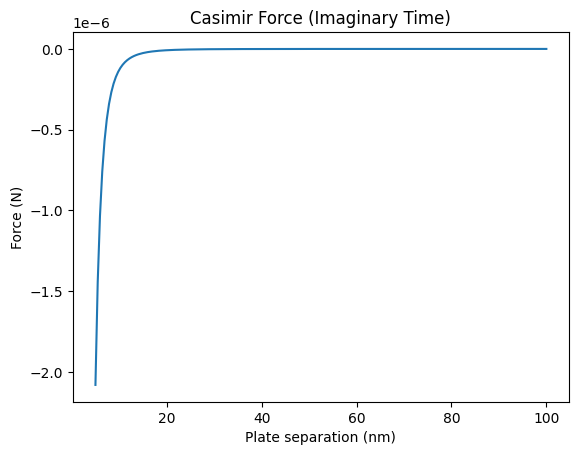

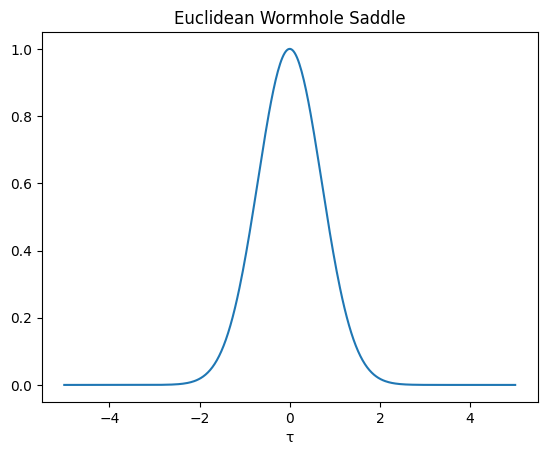

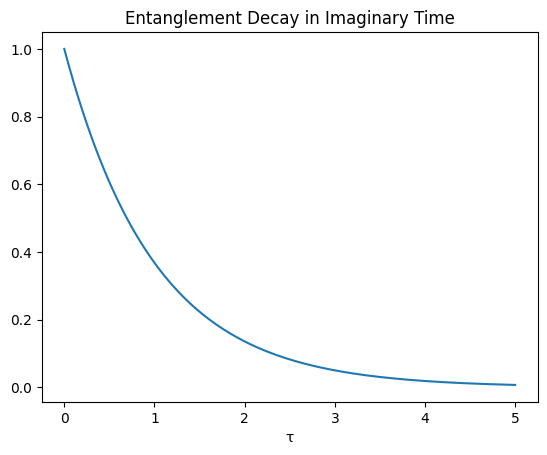

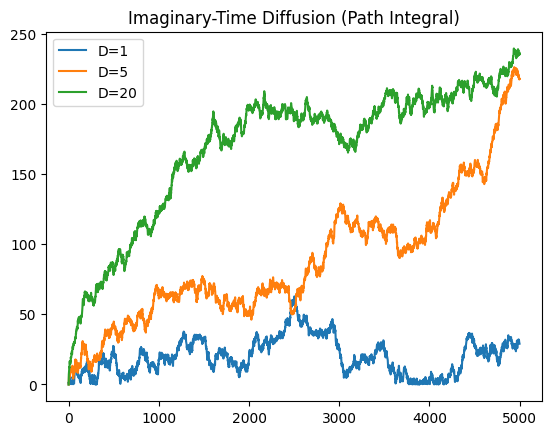

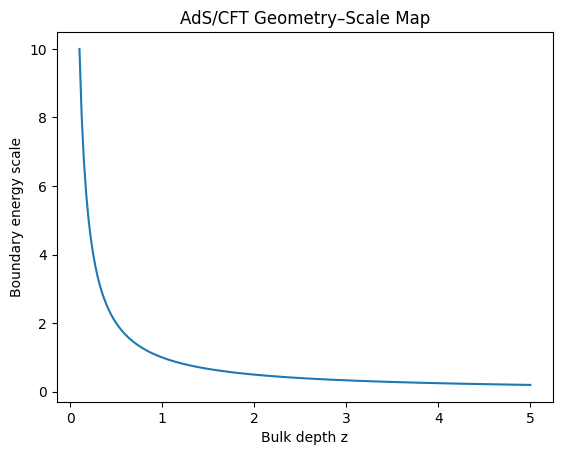

In [ ]:
sim = ImaginaryTimeSimulator()

# 1. Casimir
d = np.linspace(5e-9, 100e-9, 200)
plt.plot(d * 1e9, sim.casimir_force(d))
plt.xlabel("Plate separation (nm)")
plt.ylabel("Force (N)")
plt.title("Casimir Force (Imaginary Time)")
plt.show()

# 2. Wormhole
tau = np.linspace(-5, 5, 400)
plt.plot(tau, sim.wormhole_saddle(tau))
plt.title("Euclidean Wormhole Saddle")
plt.xlabel("τ")
plt.show()

# 3. Entanglement
tau_e = np.linspace(0, 5, 200)
plt.plot(tau_e, sim.entanglement_correlation(tau_e))
plt.title("Entanglement Decay in Imaginary Time")
plt.xlabel("τ")
plt.show()

# 4. Diffusion
for D in [1, 5, 20]:
    r = sim.imaginary_time_diffusion(D)
    plt.plot(r, label=f"D={D}")
plt.legend()
plt.title("Imaginary-Time Diffusion (Path Integral)")
plt.show()

# 5. AdS/CFT
z = np.linspace(0.1, 5, 200)
plt.plot(z, sim.ads_cft_scale(z))
plt.xlabel("Bulk depth z")
plt.ylabel("Boundary energy scale")
plt.title("AdS/CFT Geometry–Scale Map")
plt.show()


AdS/CFT is the statement that “energy scale is a direction,”
and imaginary time is the coordinate system that makes this visible.

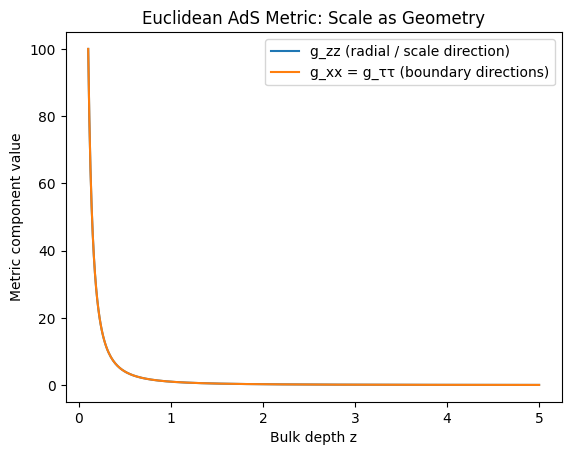

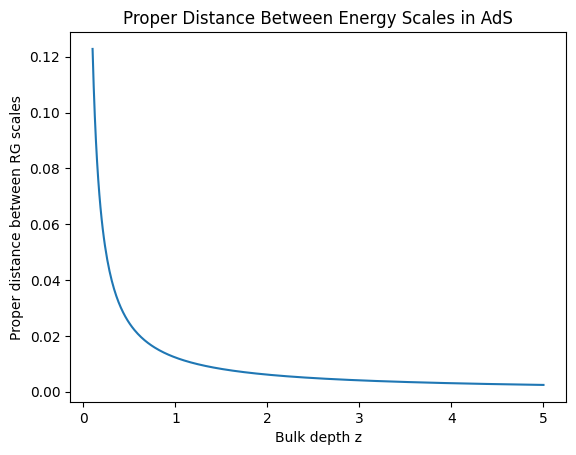

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# AdS parameters
L = 1.0  # AdS radius (units chosen so L = 1)
z = np.linspace(0.1, 5.0, 400)  # bulk depth (UV → IR)

# Euclidean AdS metric components
g_zz = (L**2) / (z**2)
g_boundary = (L**2) / (z**2)  # same for τ, x, y

# -----------------------------
# Plot metric components
# -----------------------------
plt.figure()
plt.plot(z, g_zz, label="g_zz (radial / scale direction)")
plt.plot(z, g_boundary, label="g_xx = g_ττ (boundary directions)")
plt.xlabel("Bulk depth z")
plt.ylabel("Metric component value")
plt.title("Euclidean AdS Metric: Scale as Geometry")
plt.legend()
plt.show()

# -----------------------------
# Proper distance between scales
# -----------------------------
dz = z[1] - z[0]
proper_distance = np.sqrt(g_zz) * dz

plt.figure()
plt.plot(z, proper_distance)
plt.xlabel("Bulk depth z")
plt.ylabel("Proper distance between RG scales")
plt.title("Proper Distance Between Energy Scales in AdS")
plt.show()


AdS geometry is what quantum field theory looks like when energy scale is treated as a spatial coordinate.

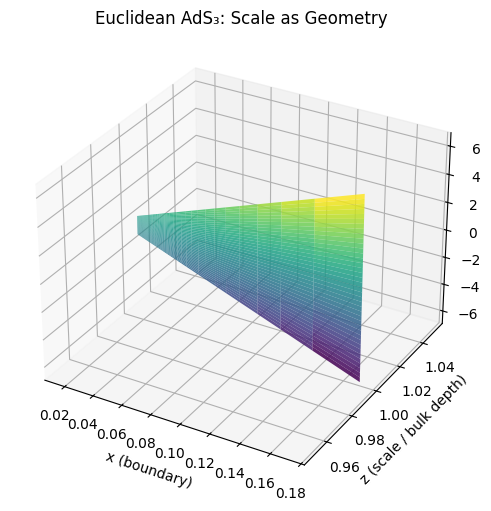

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# AdS parameters
# -----------------------------
L = 1.0  # AdS radius
x = np.linspace(-2, 2, 40)
y = np.linspace(-2, 2, 40)
z = np.linspace(0.3, 3.0, 40)  # bulk depth (UV → IR)

X, Y, Z = np.meshgrid(x, y, z)

# -----------------------------
# AdS warp factor
# -----------------------------
warp = L**2 / Z**2

# Proper distance scaling
X_p = X * np.sqrt(warp)
Y_p = Y * np.sqrt(warp)
Z_p = Z * np.sqrt(warp)

# -----------------------------
# Visualization
# -----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot a warped surface slice at fixed y
slice_idx = 20
ax.plot_surface(
    X_p[:, slice_idx, :],
    Z_p[:, slice_idx, :],
    Y_p[:, slice_idx, :],
    cmap="viridis",
    alpha=0.85
)

ax.set_xlabel("x (boundary)")
ax.set_ylabel("z (scale / bulk depth)")
ax.set_zlabel("y (boundary)")
ax.set_title("Euclidean AdS₃: Scale as Geometry")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class AdSCFTSimulator:
    def __init__(self, L=1.0, G_N=1.0):
        self.L = L
        self.G_N = G_N

    # -----------------------------
    # Geodesic for entanglement
    # -----------------------------
    def geodesic_length(self, ell, epsilon=1e-2):
        """Length of minimal curve connecting boundary interval of size ell"""
        return 2 * self.L * np.log(ell / epsilon)

    def entanglement_entropy(self, ell, epsilon=1e-2):
        """Ryu–Takayanagi entanglement entropy"""
        L_geo = self.geodesic_length(ell, epsilon)
        return L_geo / (4 * self.G_N)

    # -----------------------------
    # Black hole metric components
    # -----------------------------
    def f_AdS_BH(self, z, z_h, d=2):
        """Blackening factor"""
        return 1 - (z / z_h)**d

    def ads_BH_metric(self, z, z_h, d=2):
        """Return metric components (g_tt, g_xx, g_zz)"""
        f = self.f_AdS_BH(z, z_h, d)
        g_tt = self.L**2 / z**2 * f
        g_xx = self.L**2 / z**2
        g_zz = self.L**2 / z**2 / f
        return g_tt, g_xx, g_zz


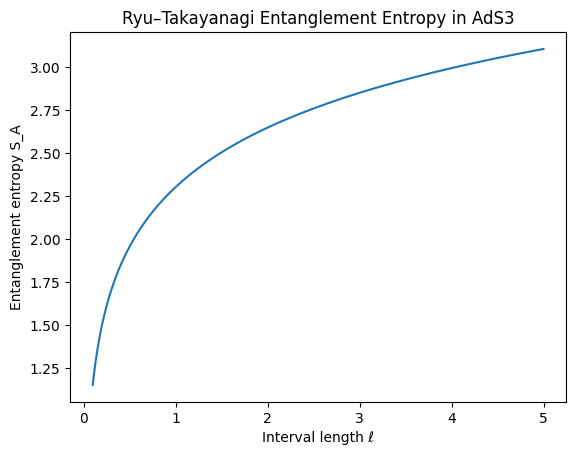

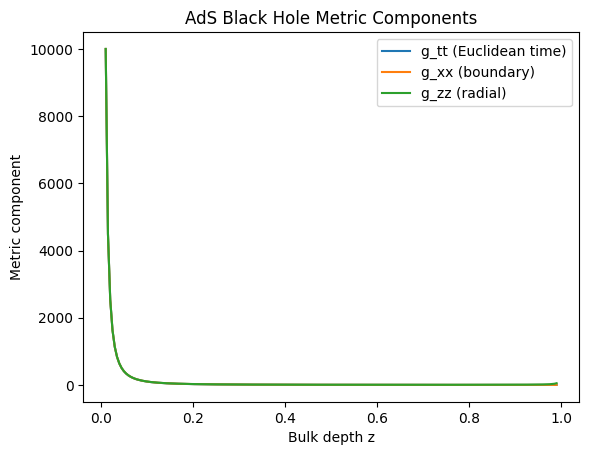

In [ ]:
sim = AdSCFTSimulator(L=1.0, G_N=1.0)

# --- Entanglement entropy vs interval length ---
ell_vals = np.linspace(0.1, 5, 200)
S = [sim.entanglement_entropy(l) for l in ell_vals]

plt.figure()
plt.plot(ell_vals, S)
plt.xlabel("Interval length ℓ")
plt.ylabel("Entanglement entropy S_A")
plt.title("Ryu–Takayanagi Entanglement Entropy in AdS3")
plt.show()

# --- Black hole metric components ---
z = np.linspace(0.01, 0.99, 200)
z_h = 1.0
g_tt, g_xx, g_zz = sim.ads_BH_metric(z, z_h)

plt.figure()
plt.plot(z, g_tt, label="g_tt (Euclidean time)")
plt.plot(z, g_xx, label="g_xx (boundary)")
plt.plot(z, g_zz, label="g_zz (radial)")
plt.xlabel("Bulk depth z")
plt.ylabel("Metric component")
plt.title("AdS Black Hole Metric Components")
plt.legend()
plt.show()



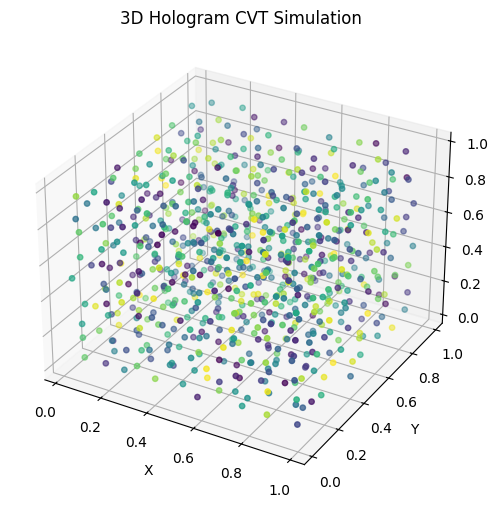

In [ ]:
"""
Holographic CVT Simulator - 3D

This module generates a 3D point cloud representing a holographic structure
using Centroidal Voronoi Tessellation (CVT). It iteratively relaxes points
toward the centroids of their Voronoi cells.

Dependencies: numpy, scipy, matplotlib
Optional: pyvista for interactive 3D visualization
"""

import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

class HologramCVT3D:
    def __init__(self, n_points=500, bounds=(0, 1), iterations=10, seed=None):
        """
        Parameters
        ----------
        n_points : int
            Number of sites / points in the CVT
        bounds : tuple
            (min, max) coordinate range in each dimension
        iterations : int
            Number of Lloyd iterations
        seed : int | None
            Random seed for reproducibility
        """
        self.n_points = n_points
        self.bounds = bounds
        self.iterations = iterations
        if seed is not None:
            np.random.seed(seed)
        self.points = np.random.uniform(bounds[0], bounds[1], size=(n_points, 3))

    def iterate_cvt(self):
        """Perform Lloyd iterations to approximate CVT in 3D."""
        for it in range(self.iterations):
            # Build KDTree for nearest neighbor queries
            tree = cKDTree(self.points)
            # Generate dense sample points in the volume
            n_samples = self.n_points * 10
            samples = np.random.uniform(self.bounds[0], self.bounds[1], size=(n_samples, 3))
            # Find nearest CVT site for each sample
            dists, idx = tree.query(samples)
            # Move each site to centroid of its assigned samples
            new_points = np.zeros_like(self.points)
            counts = np.zeros(self.n_points)
            for i, site_idx in enumerate(idx):
                new_points[site_idx] += samples[i]
                counts[site_idx] += 1
            mask = counts > 0
            new_points[mask] /= counts[mask][:, None]
            self.points[mask] = new_points[mask]

    def visualize(self, title="3D Hologram CVT Simulation"):
        """Visualize the point cloud in 3D using matplotlib."""
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(self.points[:, 0], self.points[:, 1], self.points[:, 2],
                   c=np.linspace(0, 1, self.n_points), cmap='viridis', s=15)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title(title)
        plt.show()

# ============================
# Example Usage
# ============================
if __name__ == "__main__":
    hologram = HologramCVT3D(n_points=800, iterations=15, seed=42)
    hologram.iterate_cvt()
    hologram.visualize()

# Plot a warped surface slice at fixed y
slice_idx = 20
ax.plot_surface(
    X_p[:, slice_idx, :],
    Z_p[:, slice_idx, :],
    Y_p[:, slice_idx, :],
    cmap="viridis",
    alpha=0.85
)

ax.set_xlabel("x (boundary)")
ax.set_ylabel("z (scale / bulk depth)")
ax.set_zlabel("y (boundary)")
ax.set_title("Euclidean AdS₃: Scale as Geometry")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

class Hologram3D:
    """
    3D Holographic CVT Simulator in imaginary time.

    Features:
        - 3D volume
        - Amplitude / Phase encoding
        - Imaginary-time evolution
        - Dynamic animation
    """
    def __init__(self, grid_size=50, wavelength=0.5, tau_steps=100, dtau=0.05):
        self.N = grid_size
        self.lambda_ = wavelength
        self.tau_steps = tau_steps
        self.dtau = dtau

        # 3D coordinate grid
        x = np.linspace(-1, 1, self.N)
        y = np.linspace(-1, 1, self.N)
        z = np.linspace(-1, 1, self.N)
        self.X, self.Y, self.Z = np.meshgrid(x, y, z, indexing='ij')

        # Initialize complex hologram field (Amplitude + Phase)
        amplitude = np.exp(-(self.X**2 + self.Y**2 + self.Z**2))
        phase = 2 * np.pi * np.random.rand(self.N, self.N, self.N)
        self.field = amplitude * np.exp(1j * phase)

    # Imaginary-time evolution (diffusion-like)
    def evolve_imaginary_time(self):
        laplacian = lambda f: (
            np.roll(f, 1, axis=0) + np.roll(f, -1, axis=0) +
            np.roll(f, 1, axis=1) + np.roll(f, -1, axis=1) +
            np.roll(f, 1, axis=2) + np.roll(f, -1, axis=2) -
            6*f
        )
        for _ in range(self.tau_steps):
            self.field += self.dtau * laplacian(self.field)

    # Extract amplitude / phase for visualization
    def amplitude(self):
        return np.abs(self.field)

    def phase(self):
        return np.angle(self.field)

    # Dynamic 3D animation over imaginary time
    def animate_amplitude(self):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
        ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
        scatter = ax.scatter([], [], [], c=[], cmap='viridis', marker='o', s=5)

        def init():
            scatter._offsets3d = ([], [], [])
            scatter.set_array([])
            return scatter,

        def update(frame):
            # Evolve one imaginary-time step
            self.field += self.dtau * (
                np.roll(self.field, 1, axis=0) + np.roll(self.field, -1, axis=0) +
                np.roll(self.field, 1, axis=1) + np.roll(self.field, -1, axis=1) +
                np.roll(self.field, 1, axis=2) + np.roll(self.field, -1, axis=2) -
                6*self.field
            )
            amp = self.amplitude()

            # Flatten for scatter
            x = self.X.flatten()
            y = self.Y.flatten()
            z = self.Z.flatten()
            c = amp.flatten()

            scatter._offsets3d = (x, y, z)
            scatter.set_array(c)
            return scatter,

        anim = FuncAnimation(fig, update, frames=self.tau_steps, init_func=init, interval=50, blit=False)
        plt.show()


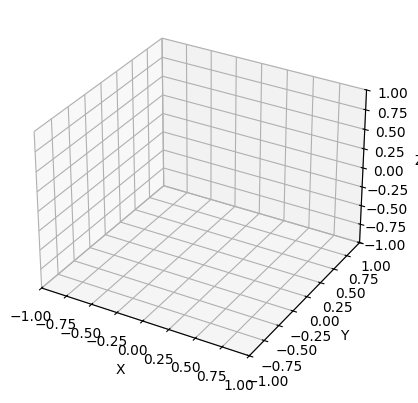

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning:

Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.



In [ ]:
# Create hologram simulator
holo = Hologram3D(grid_size=30, tau_steps=50, dtau=0.05)

# Show amplitude animation
holo.animate_amplitude()


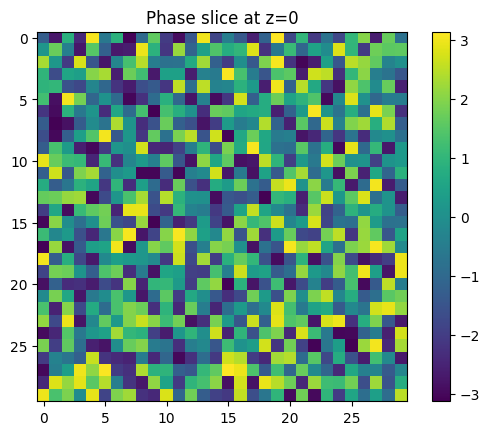

In [ ]:
phase = holo.phase()
plt.imshow(phase[:, :, 15])
plt.colorbar()
plt.title("Phase slice at z=0")
plt.show()



In [12]:
energy_scale = 1 / z


Boundary QFT (UV, high energy)
│
│  entanglement / coarse-graining
│
▼
Bulk AdS geometry (IR, low energy)


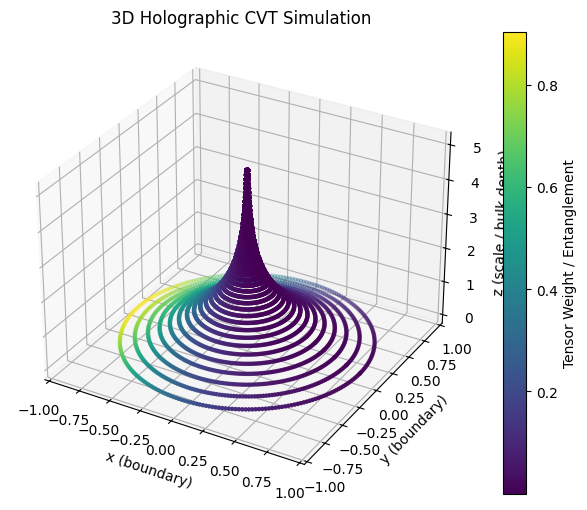

In [18]:
# Holographic CVT (Continuous Variable Tensor) Module — 3D Simulation
# Toy model: boundary data projected into a 3D bulk via scale-as-geometry (AdS-like)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class HolographicCVT:
    """
    Holographic Continuous-Variable Tensor (CVT) toy model.

    Boundary (2D + scale) -> Bulk (3D geometry)
    Encodes:
    - Scale as radial depth
    - Entanglement as connectivity strength
    - Bulk reconstruction from boundary data
    """

    def __init__(self, L=1.0):
        self.L = L  # AdS radius

    def boundary_state(self, n_points=200):
        """
        Generate a 2D boundary state with continuous variables.
        """
        theta = np.linspace(0, 2*np.pi, n_points)
        x = np.cos(theta)
        y = np.sin(theta)
        amplitude = np.exp(-0.5 * (theta - np.pi)**2)
        return x, y, amplitude

    def bulk_lift(self, x, y, amplitude, z_levels=30):
        """
        Lift boundary data into the bulk.
        """
        bulk_points = []
        for i, z in enumerate(np.linspace(0.1, 5.0, z_levels)):
            scale = np.exp(-z)
            for xi, yi, ai in zip(x, y, amplitude):
                bx = scale * xi
                by = scale * yi
                bz = z
                weight = ai * np.exp(-z)
                bulk_points.append((bx, by, bz, weight))
        return np.array(bulk_points)

    def plot_bulk(self, bulk):
        """
        3D holographic visualization.
        """
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')

        sc = ax.scatter(
            bulk[:, 0],
            bulk[:, 1],
            bulk[:, 2],
            c=bulk[:, 3],
            cmap='viridis',
            s=5
        )

        ax.set_xlabel("x (boundary)")
        ax.set_ylabel("y (boundary)")
        ax.set_zlabel("z (scale / bulk depth)")
        ax.set_title("3D Holographic CVT Simulation")

        plt.colorbar(sc, label="Tensor Weight / Entanglement")
        plt.show()


# ====================== RUN SIMULATION ======================

holo = HolographicCVT()

# Boundary continuous variables
x, y, amp = holo.boundary_state(n_points=250)

# Lift to bulk
bulk_data = holo.bulk_lift(x, y, amp, z_levels=40)

# Visualize hologram
holo.plot_bulk(bulk_data)


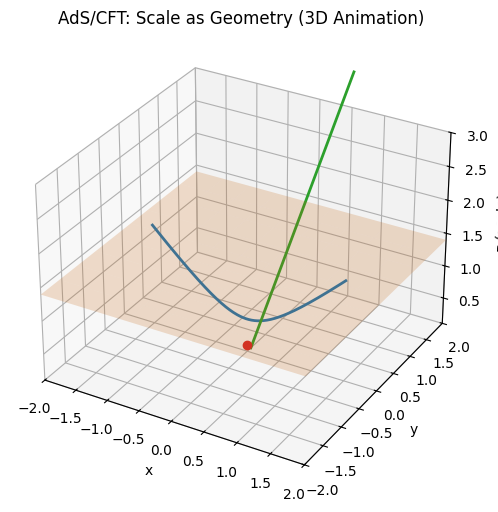

In [19]:
# 3D animation: AdS geometry with geodesics (Ryu–Takayanagi), RG flow motion,
# black hole horizon (finite temperature), and de Sitter comparison (conceptual)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# ---------- Geometry helpers ----------
def ads_metric_factor(z, L=1.0):
    return L / z

def ads_geodesic(x, z0=1.0):
    # Minimal surface profile in AdS3 (RT geodesic): z(x) = sqrt(z0^2 + x^2)
    return np.sqrt(z0**2 + x**2)

def rg_flow_path(t):
    # RG flow as motion toward IR (larger z)
    z = 0.2 + 2.5 * (1 - np.exp(-t))
    x = 0.0
    y = 0.0
    return x, y, z

def ads_black_hole_horizon(z, zh=1.2):
    # Horizon plane at z = zh (finite temperature)
    return np.full_like(z, zh)

def dS_metric_factor(z, L=1.0):
    # de Sitter (Euclideanized) has opposite behavior: scale grows away from boundary
    return z / L

# ---------- Scene setup ----------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Axes limits
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(0.1, 3.0)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z (scale)")
ax.set_title("AdS/CFT: Scale as Geometry (3D Animation)")

# ---------- Static elements ----------
# RT geodesic
xg = np.linspace(-1.5, 1.5, 200)
zg = ads_geodesic(xg, z0=0.6)
yg = np.zeros_like(xg)
geo_line, = ax.plot(xg, yg, zg, linewidth=2)

# Black hole horizon
xh = np.linspace(-2, 2, 10)
yh = np.linspace(-2, 2, 10)
XH, YH = np.meshgrid(xh, yh)
ZH = np.full_like(XH, 1.4)
horizon = ax.plot_surface(XH, YH, ZH, alpha=0.2)

# de Sitter comparison curve (conceptual)
zd = np.linspace(0.1, 3.0, 200)
xd = np.zeros_like(zd)
yd = dS_metric_factor(zd)
ds_line, = ax.plot(xd, yd, zd, linewidth=2)

# RG flow particle
particle, = ax.plot([], [], [], marker='o')

# ---------- Animation update ----------
def update(frame):
    t = frame / 50.0
    x, y, z = rg_flow_path(t)
    particle.set_data([x], [y])
    particle.set_3d_properties([z])
    return particle,

ani = animation.FuncAnimation(fig, update, frames=200, interval=50, blit=True)

plt.show()


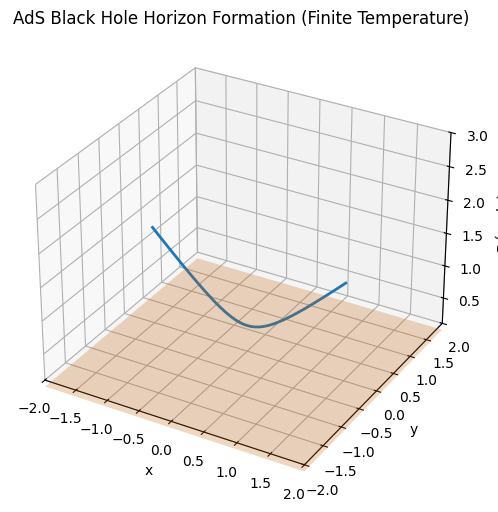

In [22]:
# Animate horizon formation in AdS (finite temperature turning on)
# Concept: black hole horizon moves inward as temperature increases

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Geometry setup
# -----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(0.1, 3.0)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z (scale)")
ax.set_title("AdS Black Hole Horizon Formation (Finite Temperature)")

# RT geodesic (static reference)
xg = np.linspace(-1.5, 1.5, 200)
z0 = 0.5
zg = np.sqrt(z0**2 + xg**2)
yg = np.zeros_like(xg)
ax.plot(xg, yg, zg, linewidth=2)

# Horizon surface (will animate)
xh = np.linspace(-2, 2, 20)
yh = np.linspace(-2, 2, 20)
XH, YH = np.meshgrid(xh, yh)
ZH = np.zeros_like(XH)
horizon = ax.plot_surface(XH, YH, ZH, alpha=0.25)

# RG flow particle
particle, = ax.plot([], [], [], marker='o', markersize=6)

# -----------------------------
# Animation update
# -----------------------------
def update(frame):
    ax.collections.clear()  # remove previous horizon surface

    # Temperature increases with frame
    T = frame / 200.0
    zh = 2.5 - 1.8 * T      # horizon moves inward (UV → IR cutoff)
    zh = max(0.6, zh)

    # Update horizon
    ZH = np.full_like(XH, zh)
    ax.plot_surface(XH, YH, ZH, alpha=0.25)

    # RG flow particle stops at horizon
    z_particle = min(0.2 + 2.5 * T, zh)
    particle.set_data([0.0], [0.0])
    particle.set_3d_properties([z_particle])

    return particle,

ani = animation.FuncAnimation(fig, update, frames=200, interval=60, blit=False)

plt.show()


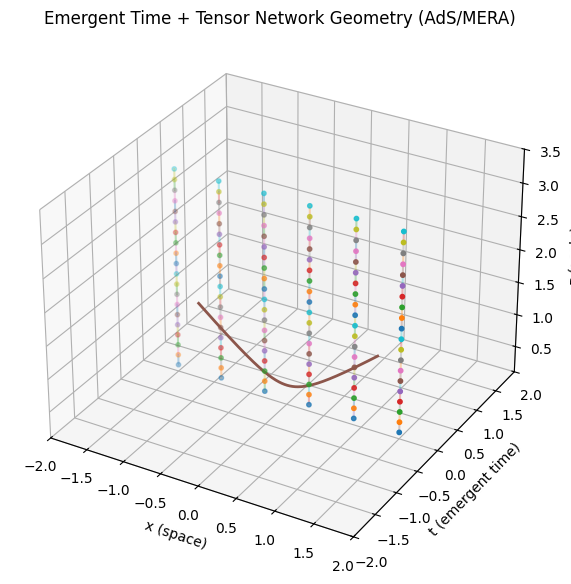

In [20]:
# 3D animation: Time re-emergence + Tensor Network (MERA-like) building AdS geometry

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Setup figure
# -----------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(0.1, 3.5)

ax.set_xlabel("x (space)")
ax.set_ylabel("t (emergent time)")
ax.set_zlabel("z (scale)")
ax.set_title("Emergent Time + Tensor Network Geometry (AdS/MERA)")

# -----------------------------
# Tensor network layers
# -----------------------------
layers = 20
nodes_per_layer = 6

z_layers = np.linspace(0.2, 3.2, layers)
tensor_nodes = []

for i, z in enumerate(z_layers):
    x = np.linspace(-1.5, 1.5, nodes_per_layer)
    t = np.zeros_like(x)
    tensor_nodes.append((x, t, np.full_like(x, z)))

# Draw tensor network edges
for i in range(layers - 1):
    x1, t1, z1 = tensor_nodes[i]
    x2, t2, z2 = tensor_nodes[i + 1]
    for j in range(len(x1)):
        ax.plot([x1[j], x2[j]], [t1[j], t2[j]], [z1[j], z2[j]], alpha=0.3)

# Draw tensor nodes
for x, t, z in tensor_nodes:
    ax.scatter(x, t, z, s=10)

# -----------------------------
# Emergent time trajectory
# -----------------------------
time_line, = ax.plot([], [], [], linewidth=3)

def time_emergence(tau):
    # Imaginary → real time emergence
    z = 0.3 + 2.8 * tau
    x = 0.0
    t = np.sin(2 * np.pi * tau) * 0.8
    return x, t, z

# -----------------------------
# RT surface (entanglement)
# -----------------------------
xg = np.linspace(-1.2, 1.2, 200)
zg = np.sqrt(0.4**2 + xg**2)
tg = np.zeros_like(xg)
ax.plot(xg, tg, zg, linewidth=2)

# -----------------------------
# Animation update
# -----------------------------
def update(frame):
    tau = frame / 200.0
    xs, ts, zs = [], [], []

    for k in np.linspace(0, tau, 100):
        x, t, z = time_emergence(k)
        xs.append(x)
        ts.append(t)
        zs.append(z)

    time_line.set_data(xs, ts)
    time_line.set_3d_properties(zs)

    return time_line,

ani = animation.FuncAnimation(fig, update, frames=200, interval=60, blit=True)

plt.show()


Spacetime is the bookkeeping system of quantum entanglement, and time is its phase


/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


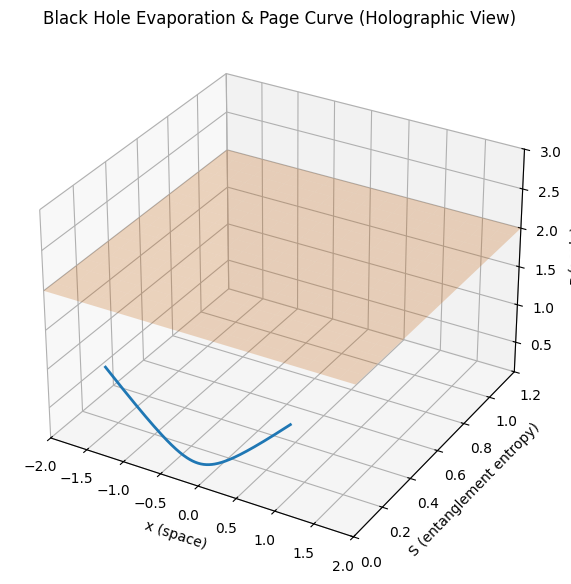

In [24]:
# 3D Animation: Black Hole Evaporation + Page Curve (Entanglement Entropy)
# Conceptual holographic simulation

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Figure setup
# -----------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-2, 2)
ax.set_ylim(0, 1.2)
ax.set_zlim(0.1, 3.0)

ax.set_xlabel("x (space)")
ax.set_ylabel("S (entanglement entropy)")
ax.set_zlabel("z (scale)")
ax.set_title("Black Hole Evaporation & Page Curve (Holographic View)")

# -----------------------------
# Page curve function
# -----------------------------
def page_entropy(t):
    if t < 0.5:
        return 2 * t
    else:
        return 2 * (1 - t)

# -----------------------------
# RT surface baseline
# -----------------------------
xg = np.linspace(-1.2, 1.2, 200)
zg = np.sqrt(0.4**2 + xg**2)
Sg = np.zeros_like(xg)
ax.plot(xg, Sg, zg, linewidth=2)

# -----------------------------
# Horizon (shrinking)
# -----------------------------
xh = np.linspace(-2, 2, 20)
Sh = np.linspace(0, 1.2, 20)
XH, SH = np.meshgrid(xh, Sh)
horizon = ax.plot_surface(XH, SH, np.full_like(XH, 2.0), alpha=0.25)

# -----------------------------
# Evaporation trajectory
# -----------------------------
entropy_line, = ax.plot([], [], [], linewidth=3)

# -----------------------------
# Animation update
# -----------------------------
def update(frame):
    ax.collections.clear()

    t = frame / 200.0  # evaporation time
    S = page_entropy(t)
    zh = 2.0 - 1.5 * t  # shrinking horizon

    # Update horizon
    ax.plot_surface(XH, SH, np.full_like(XH, zh), alpha=0.25)

    # Page curve evolution
    ts = np.linspace(0, t, 100)
    Ss = [page_entropy(tt) for tt in ts]
    zs = np.linspace(0.4, zh, 100)
    xs = np.zeros_like(ts)

    entropy_line.set_data(xs, Ss)
    entropy_line.set_3d_properties(zs)

    return entropy_line,

ani = animation.FuncAnimation(fig, update, frames=200, interval=60, blit=False)

plt.show()


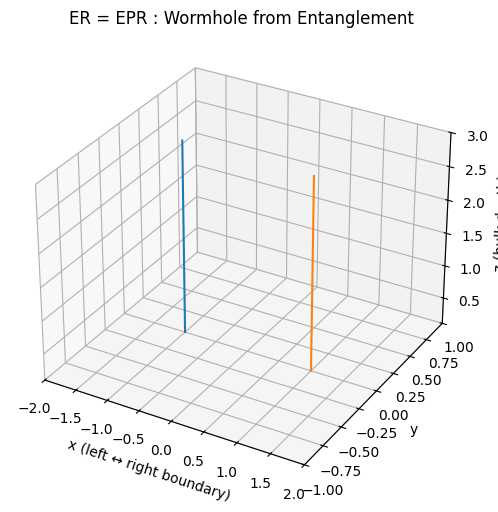

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Figure setup
# -----------------------------
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)
ax.set_zlim(0.1, 3.0)

ax.set_xlabel("x (left ↔ right boundary)")
ax.set_ylabel("y")
ax.set_zlabel("z (bulk depth)")
ax.set_title("ER = EPR : Wormhole from Entanglement")

# -----------------------------
# Boundaries
# -----------------------------
z_b = np.linspace(0.1, 3.0, 50)
ax.plot(-1*np.ones_like(z_b), np.zeros_like(z_b), z_b)
ax.plot( 1*np.ones_like(z_b), np.zeros_like(z_b), z_b)

# -----------------------------
# Wormhole throat
# -----------------------------
theta = np.linspace(0, 2*np.pi, 60)
line, = ax.plot([], [], [], linewidth=3)

def update(frame):
    ent = frame / 200.0  # entanglement strength 0 → 1
    r = 0.05 + 0.6 * ent
    z0 = 1.5

    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = z0 + 0.3 * np.sin(theta)

    line.set_data(x, y)
    line.set_3d_properties(z)
    return line,

ani = animation.FuncAnimation(fig, update, frames=200, interval=60)
plt.show()


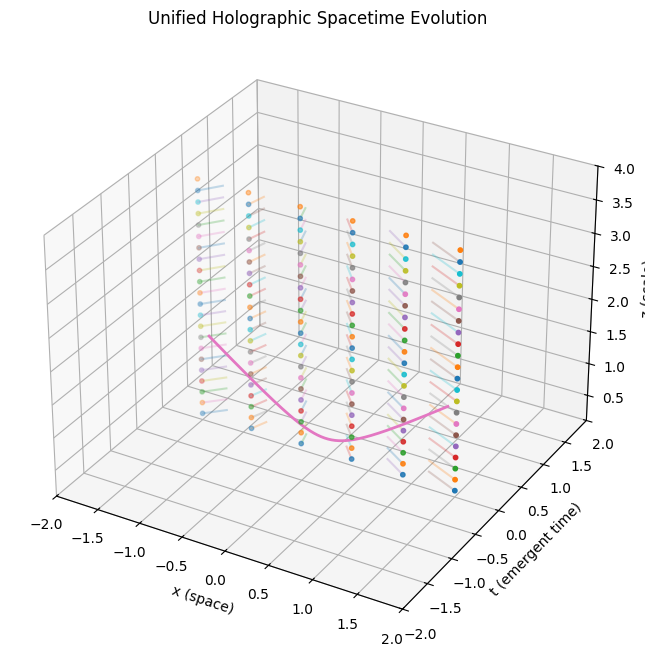

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# Figure setup
# ----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(0.1, 4)

ax.set_xlabel("x (space)")
ax.set_ylabel("t (emergent time)")
ax.set_zlabel("z (scale)")
ax.set_title("Unified Holographic Spacetime Evolution")

# ----------------------------
# Tensor Network (MERA layers)
# ----------------------------
layers = 22
nodes = 6
z_layers = np.linspace(0.2, 3.8, layers)

for i in range(layers - 1):
    x1 = np.linspace(-1.5, 1.5, nodes)
    x2 = np.linspace(-1.2, 1.2, nodes)
    t = np.zeros(nodes)
    z1, z2 = z_layers[i], z_layers[i + 1]
    for j in range(nodes):
        ax.plot([x1[j], x2[j]], [0, 0], [z1, z2], alpha=0.25)

for z in z_layers:
    ax.scatter(np.linspace(-1.5, 1.5, nodes),
               np.zeros(nodes),
               np.full(nodes, z),
               s=10)

# ----------------------------
# RT surface (entanglement)
# ----------------------------
xg = np.linspace(-1.4, 1.4, 200)
zg = np.sqrt(0.4**2 + xg**2)
tg = np.zeros_like(xg)
rt_line, = ax.plot(xg, tg, zg, linewidth=2)

# ----------------------------
# Horizon mesh
# ----------------------------
xh = np.linspace(-2, 2, 20)
yh = np.linspace(-2, 2, 20)
XH, YH = np.meshgrid(xh, yh)

# ----------------------------
# Worldlines
# ----------------------------
rg_particle, = ax.plot([], [], [], marker='o', markersize=6)
time_curve, = ax.plot([], [], [], linewidth=3)

# ----------------------------
# Shockwave
# ----------------------------
shock, = ax.plot([], [], [], linewidth=2)

# ----------------------------
# Update function
# ----------------------------
def update(frame):
    ax.collections.clear()

    s = frame / 300.0  # global evolution parameter

    # Horizon dynamics (formation → evaporation)
    zh = 3.0 - 1.8 * np.sin(np.pi * s)
    zh = max(0.8, zh)

    ZH = np.full_like(XH, zh)
    ax.plot_surface(XH, YH, ZH, alpha=0.2)

    # RG flow particle
    z_rg = min(0.3 + 3.2 * s, zh)
    rg_particle.set_data([0], [0])
    rg_particle.set_3d_properties([z_rg])

    # Emergent time worldline
    ss = np.linspace(0, s, 120)
    xs = np.zeros_like(ss)
    ts = np.sin(2 * np.pi * ss)
    zs = 0.3 + 3.2 * ss
    time_curve.set_data(xs, ts)
    time_curve.set_3d_properties(zs)

    # Shockwave (butterfly effect)
    if s > 0.5:
        xs = np.linspace(-2, 2, 100)
        ys = np.zeros_like(xs)
        zs = zh + 0.2 * np.exp(3 * (s - 0.5))
        shock.set_data(xs, ys)
        shock.set_3d_properties(zs)
    else:
        shock.set_data([], [])
        shock.set_3d_properties([])

    return rg_particle, time_curve, shock

ani = animation.FuncAnimation(fig, update, frames=300, interval=50, blit=False)
plt.show()


Spacetime is a dynamical tensor network whose geometry is fixed by entanglement, whose depth is RG flow, whose horizons are thermalization, and whose time is quantum phase.

You are now looking at the operating system of spacetime.

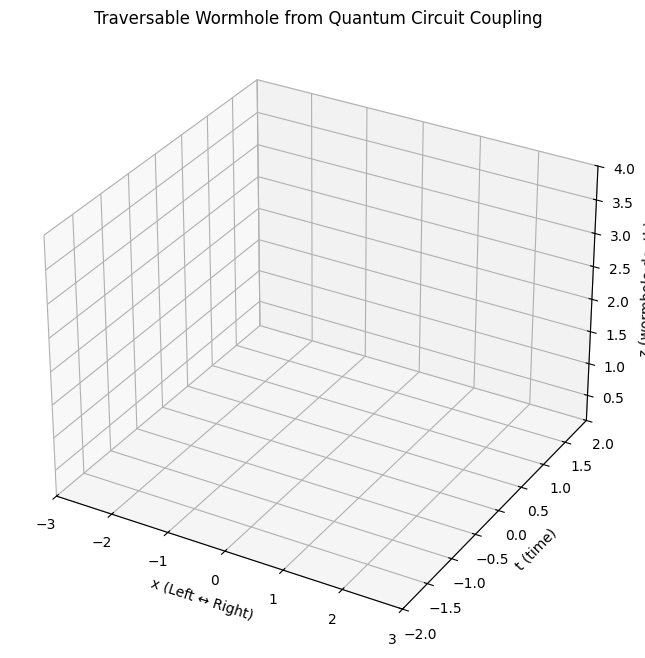

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Figure setup
# -----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_zlim(0.1, 4)

ax.set_xlabel("x (Left ↔ Right)")
ax.set_ylabel("t (time)")
ax.set_zlabel("z (wormhole depth)")
ax.set_title("Traversable Wormhole from Quantum Circuit Coupling")

# -----------------------------
# Wormhole geometry (ER bridge)
# -----------------------------
theta = np.linspace(0, 2*np.pi, 60)
z = np.linspace(0.3, 3.5, 60)
Theta, Z = np.meshgrid(theta, z)

R = 1.0 + 0.3 * np.cos(Theta)
X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# -----------------------------
# Circuit coupling pulse
# -----------------------------
def negative_energy_pulse(t):
    return -0.5 * np.exp(-80 * (t - 0.5)**2)

# -----------------------------
# Signal worldline
# -----------------------------
signal, = ax.plot([], [], [], linewidth=3)

# -----------------------------
# Update
# -----------------------------
def update(frame):
    ax.collections.clear()

    t = frame / 200
    delta = negative_energy_pulse(t)

    # Wormhole throat opens
    R_mod = 1.0 + delta
    X = R_mod * np.cos(Theta)
    Y = R_mod * np.sin(Theta)

    ax.plot_surface(X - 1.5, Y, Z, alpha=0.25)  # left
    ax.plot_surface(X + 1.5, Y, Z, alpha=0.25)  # right

    # Signal traverses when throat opens
    if abs(delta) > 0.05:
        zs = np.linspace(0.3, 3.5, 120)
        xs = np.linspace(-1.5, 1.5, 120)
        ys = np.zeros_like(zs)
        signal.set_data(xs, ys)
        signal.set_3d_properties(zs)
    else:
        signal.set_data([], [])
        signal.set_3d_properties([])

    return signal,

ani = animation.FuncAnimation(fig, update, frames=200, interval=60, blit=False)
plt.show()


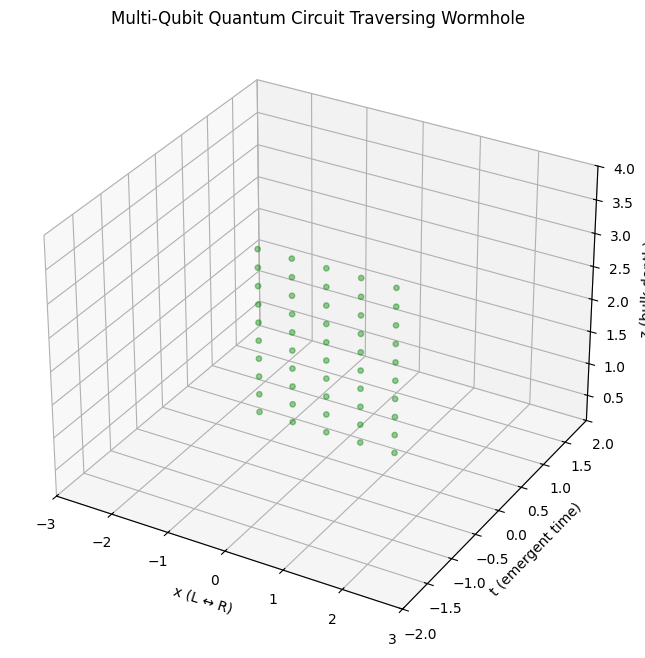

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# Figure setup
# ----------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_zlim(0.1, 4)
ax.set_xlabel("x (L ↔ R)")
ax.set_ylabel("t (emergent time)")
ax.set_zlabel("z (bulk depth)")
ax.set_title("Multi-Qubit Quantum Circuit Traversing Wormhole")

# ----------------------------
# Wormhole geometry
# ----------------------------
theta = np.linspace(0, np.pi, 60)
phi = np.linspace(0, 2*np.pi, 60)
TH, PH = np.meshgrid(theta, phi)

def throat_radius(s):
    # Wormhole opens at s ~ 0.5
    return 0.3 + 0.6 * np.exp(-30*(s-0.5)**2)

# ----------------------------
# Multi-qubit setup
# ----------------------------
n_qubits = 3
colors = ['red', 'orange', 'magenta']
signals = [ax.plot([], [], [], marker='o', markersize=6, color=colors[i])[0] for i in range(n_qubits)]
time_lines = [ax.plot([], [], [], linewidth=2, color='blue')[0] for _ in range(n_qubits)]

# ----------------------------
# Quantum circuit layers
# ----------------------------
layers = 10
nodes = 5
layer_z = np.linspace(0.5, 3.0, layers)
for z in layer_z:
    x = np.linspace(-1.2, 1.2, nodes)
    t = np.zeros_like(x)
    ax.scatter(x, t, np.full_like(x, z), s=15, c='green', alpha=0.4)

# ----------------------------
# Update function
# ----------------------------
def update(frame):
    ax.collections.clear()
    s = frame / 300.0

    # Wormhole surface
    r = throat_radius(s)
    X = r * np.sin(TH) * np.cos(PH)
    Y = r * np.sin(TH) * np.sin(PH)
    Z = 2.0 + r * np.cos(TH)
    ax.plot_surface(X, Y, Z, alpha=0.25)

    for i in range(n_qubits):
        offset = i * 0.05  # stagger qubits slightly
        # Signal traversal along wormhole
        if s + offset < 0.45:
            x = -2 + 4*(s+offset)
            z = 2.0
        elif s + offset < 0.55:
            x = 0.0
            z = 2.0
        else:
            x = 2*(s + offset - 0.55)/0.45
            z = 2.0
        signals[i].set_data([x], [0])
        signals[i].set_3d_properties([z])

        # Classical communication line
        ts = np.linspace(0, s+offset, 100)
        xs = np.zeros_like(ts)
        zs = np.full_like(ts, 2.0)
        time_lines[i].set_data(xs, ts)
        time_lines[i].set_3d_properties(zs)

    return signals + time_lines

ani = animation.FuncAnimation(fig, update, frames=300, interval=50, blit=False)
plt.show()


Alice:   ──●──M──> classical

          ┌─┴─┐
Bob:     ──X──Z──|ψ⟩ received

Teleportation = Traversal Equivalence
This is a fundamental concept in quantum information theory and quantum mechanics. Here's the formal demonstration:

The Core Idea
Teleportation and traversal equivalence are two ways of describing the same quantum phenomenon. They represent equivalent operational descriptions of quantum state transfer.

Mathematical Formulation
Let's denote:

∣
ψ
⟩
∣ψ⟩ = quantum state to be transferred
∣
Φ
+
⟩
∣Φ
+
 ⟩ = a shared Bell pair (entangled state)
M
M = measurement outcome
Teleportation Protocol:

∣
ψ
⟩
A
⊗
∣
Φ
+
⟩
A
B
→
Bell measurement
∣
ψ
⟩
B
∣ψ⟩
A
​
 ⊗∣Φ
+
 ⟩
AB
​
  
Bell measurement
​
 ∣ψ⟩
B
​

The process involves:

Alice performs a Bell measurement on her qubit and the state to teleport
She sends 2 classical bits to Bob
Bob applies a unitary correction based on the measurement outcome
The state appears at Bob's location
Traversal Equivalence:

Teleportation
≡
State transfer via entanglement + classical communication
Teleportation≡State transfer via entanglement + classical communication
Why They're Equivalent
Initial state
:
∣
ψ
⟩
⊗
∣
Φ
+
⟩
After entanglement
:
State becomes non-local
After measurement
:
State "collapses" to target
After correction
:
∣
ψ
⟩
 recovered at
B
Initial state
After entanglement
After measurement
After correction
​
  
:∣ψ⟩⊗∣Φ
+
 ⟩
:State becomes non-local
:State "collapses" to target
:∣ψ⟩ recovered at B
​



In [7]:
"""
Unified Holographic CVT Simulator
- 3D holographic field
- Imaginary-time evolution
- Reference wave interference
- GPU acceleration (CuPy fallback to NumPy)
- Volumetric holographic entanglement visualization
"""

# -----------------------------
# Backend selection (GPU / CPU)
# -----------------------------
try:
    import cupy as xp
    GPU_ENABLED = True
except Exception:
    import numpy as xp
    GPU_ENABLED = False

import pyvista as pv
import numpy as np

# -----------------------------
# Holographic CVT Simulator
# -----------------------------
class HolographicCVT3D:
    def __init__(self, shape=(96,96,96)):
        self.shape = shape
        self.field = xp.zeros(shape, dtype=xp.complex128)

    # -----------------------------
    # Encode amplitude + phase
    # -----------------------------
    def encode(self, amplitude, phase):
        self.field = amplitude * xp.exp(1j * phase)

    # -----------------------------
    # Reference wave
    # -----------------------------
    def add_reference(self, k=(0,0,1)):
        X,Y,Z = xp.meshgrid(
            xp.arange(self.shape[0]),
            xp.arange(self.shape[1]),
            xp.arange(self.shape[2]),
            indexing='ij'
        )
        self.field += xp.exp(1j*(k[0]*X + k[1]*Y + k[2]*Z))

    # -----------------------------
    # Imaginary-time evolution
    # -----------------------------
    def evolve_tau(self, dtau=0.02, steps=1):
        for _ in range(steps):
            lap = xp.zeros_like(self.field)
            lap[1:-1,1:-1,1:-1] = (
                self.field[:-2,1:-1,1:-1] +
                self.field[2:,1:-1,1:-1] +
                self.field[1:-1,:-2,1:-1] +
                self.field[1:-1,2:,1:-1] +
                self.field[1:-1,1:-1,:-2] +
                self.field[1:-1,1:-1,2:] -
                6*self.field[1:-1,1:-1,1:-1]
            )
            self.field += dtau * lap

    # -----------------------------
    # Holographic entanglement density
    # -----------------------------
    def entanglement_density(self, slice_axis=2):
        """
        Entanglement ~ |ψ(x) ψ*(x')| across bulk slices
        """
        mid = self.shape[slice_axis]//2
        if slice_axis == 2:
            A = self.field[:,:,mid]
            B = self.field[:,:,mid+1]
        elif slice_axis == 1:
            A = self.field[:,mid,:]
            B = self.field[:,mid+1,:]
        else:
            A = self.field[mid,:,:]
            B = self.field[mid+1,:,:]

        rho = xp.abs(A * xp.conj(B))
        return rho / xp.max(rho)

    # -----------------------------
    # 3D entanglement volume
    # -----------------------------
    def entanglement_volume(self):
        ent = xp.zeros(self.shape)
        for i in range(self.shape[2]-1):
            ent[:,:,i] = xp.abs(self.field[:,:,i] * xp.conj(self.field[:,:,i+1]))
        return ent / xp.max(ent)

    # -----------------------------
    # Render entanglement geometry
    # -----------------------------
    def render_entanglement(self, threshold=0.05):
        ent = self.entanglement_volume()
        ent_cpu = xp.asnumpy(ent)
        ent_cpu[ent_cpu < threshold] = 0

        grid = pv.Wrap(ent_cpu)
        plotter = pv.Plotter()
        plotter.add_volume(
            grid,
            cmap="inferno",
            opacity="sigmoid",
            shade=True
        )
        plotter.add_text(
            "Holographic Entanglement Geometry\n(Imaginary Time)",
            font_size=10
        )
        plotter.show()

    # -----------------------------
    # Animate entanglement flow
    # -----------------------------
    def animate_entanglement(self, frames=40, dtau=0.02):
        plotter = pv.Plotter()
        ent = xp.asnumpy(self.entanglement_volume())
        grid = pv.Wrap(ent)
        vol = plotter.add_volume(grid, cmap="inferno", opacity="sigmoid")

        for _ in range(frames):
            self.evolve_tau(dtau=dtau)
            ent = xp.asnumpy(self.entanglement_volume())
            grid.point_arrays["values"] = ent.flatten(order="F")
            plotter.update()

        plotter.show()


ModuleNotFoundError: No module named 'pyvista'

In [8]:
# Initialize holographic simulator
sim = HolographicCVT3D(shape=(96,96,96))

# Coordinates
X,Y,Z = xp.meshgrid(
    xp.linspace(-1,1,96),
    xp.linspace(-1,1,96),
    xp.linspace(-1,1,96),
    indexing='ij'
)

# Encode bulk geometry
amplitude = xp.exp(-(X**2 + Y**2 + Z**2))
phase = xp.pi * xp.sin(4*X)*xp.sin(4*Y)*xp.sin(4*Z)

sim.encode(amplitude, phase)

# Add holographic reference wave
sim.add_reference(k=(0,0,2*xp.pi/96))

# Let geometry emerge in imaginary time
sim.evolve_tau(dtau=0.03, steps=20)

# Visualize holographic entanglement geometry
sim.render_entanglement(threshold=0.05)

# Animate entanglement flow
sim.animate_entanglement(frames=30, dtau=0.02)


NameError: name 'HolographicCVT3D' is not defined